# **Instalasi Library (Jalankan Sekali)**

In [ ]:
print("Menginstal library yang diperlukan...")
print("="*60)

# Install LightGBM dengan GPU support
import subprocess
import sys
import numpy as np

try:
    # Di Colab dengan runtime GPU, pip install lightgbm biasanya
    # secara otomatis menginstal versi yang mendukung GPU
    subprocess.check_call([sys.executable, "-m", "pip", "install", "lightgbm"])
    print("LightGBM berhasil diinstal. Pastikan Anda telah memilih runtime GPU di Colab (Runtime > Change runtime type) untuk memanfaatkan dukungan GPU.")

    # Verifikasi sederhana apakah LightGBM memiliki dukungan GPU
    try:
        import lightgbm as lgb
        # Untuk memverifikasi, kita bisa mencoba membangun model dummy dengan device='gpu'
        X_dummy = np.random.rand(10, 10)  # Data dummy kecil
        y_dummy = np.random.randint(0, 2, 10)  # Label dummy kecil
        model = lgb.LGBMClassifier(device='gpu', n_estimators=1, verbosity=-1)
        model.fit(X_dummy, y_dummy)
        print("Verifikasi dukungan GPU LightGBM berhasil! (Model dummy berjalan dengan 'gpu' device)")
    except Exception as gpu_check_e:
        print(f"LightGBM terinstal, namun verifikasi dukungan GPU gagal: {gpu_check_e}")
        print("Ini mungkin karena Anda tidak menggunakan runtime GPU atau ada masalah konfigurasi lainnya.")
except Exception as e:
    print(f"Gagal menginstal LightGBM dengan dukungan GPU otomatis: {e}")
    print("Melanjutkan dengan instalasi LightGBM versi CPU sebagai fallback.")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "lightgbm"])

# Install imbalanced-learn untuk sampling (jika diperlukan di masa depan)
subprocess.check_call([sys.executable, "-m", "pip", "install", "imbalanced-learn"])

# Install Optuna untuk hyperparameter tuning (jika diperlukan)
subprocess.check_call([sys.executable, "-m", "pip", "install", "optuna"])

print("Instalasi selesai!")
print("="*60)

Menginstal library yang diperlukan...
LightGBM berhasil diinstal. Pastikan Anda telah memilih runtime GPU di Colab (Runtime > Change runtime type) untuk memanfaatkan dukungan GPU.
Verifikasi dukungan GPU LightGBM berhasil! (Model dummy berjalan dengan 'gpu' device)
Instalasi selesai!


# **Import Library, Setup, dan Mount Google Drive**

####**Import Library**

In [ ]:
# Import Library untuk Data Processing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import pickle
import psutil
import os
import gc
from datetime import datetime
import time
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Import Library untuk Machine Learning - Tree-based Models
import xgboost as xgb
import lightgbm as lgb
from sklearn.model_selection import train_test_split, StratifiedKFold, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier

# Import Library untuk Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    make_scorer, matthews_corrcoef, confusion_matrix,
    classification_report)

# Import Library untuk Deep Learning (Keras/TensorFlow)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Import Library untuk Sampling (optional, tidak dipakai untuk baseline)
from imblearn.under_sampling import RandomUnderSampler

print("Semua library berhasil diimport!")
print(f"  - TensorFlow version: {tf.__version__}")
print(f"  - XGBoost version: {xgb.__version__}")
print(f"  - LightGBM version: {lgb.__version__}")

Semua library berhasil diimport!
  - TensorFlow version: 2.19.0
  - XGBoost version: 3.1.2
  - LightGBM version: 4.6.0


####**Mount GDrive**

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
print("Google Drive berhasil di-mount!")

Mounted at /content/drive
Google Drive berhasil di-mount!


####**Setup Folder**

In [ ]:
# Definisi path
DATASET_PATH = '/content/drive/My Drive/Dataset/final_dataset.parquet'
PROCESSED_DIR = '/content/drive/My Drive/CICIIoT2025/Baseline8Multiclass/Processed_Data/'
MODELS_DIR = '/content/drive/My Drive/CICIIoT2025/Baseline8Multiclass/Models/'
RESULTS_DIR = '/content/drive/My Drive/CICIIoT2025/Baseline8Multiclass/Results/'
CHECKPOINT_DIR = '/content/drive/My Drive/CICIIoT2025/Baseline8Multiclass/Checkpoints/'
EDA_DIR = '/content/drive/My Drive/CICIIoT2025/Baseline8Multiclass/EDA_Results/'

# Membuat direktori
os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(EDA_DIR, exist_ok=True)

print(f"Folder setup selesai!")
print(f"\nPath dataset: {DATASET_PATH}")
print(f"\nFolder struktur:")
print(f"  - Processed Data: {PROCESSED_DIR}")
print(f"  - Models: {MODELS_DIR}")
print(f"  - Results: {RESULTS_DIR}")
print(f"  - Checkpoints: {CHECKPOINT_DIR}")
print(f"  - EDA Results: {EDA_DIR}")

Folder setup selesai!

Path dataset: /content/drive/My Drive/Dataset/final_dataset.parquet

Folder struktur:
  - Processed Data: /content/drive/My Drive/CICIIoT2025/Baseline8Multiclass/Processed_Data/
  - Models: /content/drive/My Drive/CICIIoT2025/Baseline8Multiclass/Models/
  - Results: /content/drive/My Drive/CICIIoT2025/Baseline8Multiclass/Results/
  - Checkpoints: /content/drive/My Drive/CICIIoT2025/Baseline8Multiclass/Checkpoints/
  - EDA Results: /content/drive/My Drive/CICIIoT2025/Baseline8Multiclass/EDA_Results/


# **Langkah 1: Pre-Processing Data**

###**1.1 Load Dataset**

In [ ]:
df = pd.read_parquet(DATASET_PATH)

print(f"Dataset berhasil diload!")
print(f"  - Total rows: {df.shape[0]:,}")
print(f"  - Total columns: {df.shape[1]}")
print(f"  - Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Dataset berhasil diload!
  - Total rows: 685,671
  - Total columns: 95
  - Memory usage: 3994.50 MB


###**1.2 Inspeksi Awal**

1.2.1 Cek Kolom dan Tipe Data

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 685671 entries, 0 to 685670
Data columns (total 95 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   device_name                           685671 non-null  object 
 1   device_mac                            685671 non-null  object 
 2   label_full                            685671 non-null  object 
 3   label1                                685671 non-null  object 
 4   label2                                685671 non-null  object 
 5   label3                                685671 non-null  object 
 6   label4                                685671 non-null  object 
 7   timestamp                             685671 non-null  object 
 8   timestamp_start                       685671 non-null  object 
 9   timestamp_end                         685671 non-null  object 
 10  log_data-ranges_avg                   685671 non-null  float64
 11  

1.2.2 Distribusi Kelas (Label2 - Original)

In [ ]:
label_col = 'label2'
class_counts_original = df[label_col].value_counts().sort_index()

print(f"\nDistribusi Kelas (8 Kategori Original):")
for label in class_counts_original.index:
    count = class_counts_original[label]
    pct = (count / len(df)) * 100
    print(f"  {label:12s}: {count:7,} ({pct:5.2f}%)")

print(f"\nTotal samples: {len(df):,}")
print(f"Jumlah kelas: {df[label_col].nunique()}")


Distribusi Kelas (8 Kategori Original):
  benign      : 400,672 (58.44%)
  bruteforce  :   6,016 ( 0.88%)
  ddos        :  56,692 ( 8.27%)
  dos         :  57,736 ( 8.42%)
  malware     :  24,177 ( 3.53%)
  mitm        :  25,490 ( 3.72%)
  recon       : 105,848 (15.44%)
  web         :   9,040 ( 1.32%)

Total samples: 685,671
Jumlah kelas: 8


In [ ]:
print(f"Persentase Kelas:")
class_pct = (class_counts_original / len(df) * 100).round(4)
print(class_pct)

Persentase Kelas:
label2
benign        58.4350
bruteforce     0.8774
ddos           8.2681
dos            8.4204
malware        3.5260
mitm           3.7175
recon         15.4371
web            1.3184
Name: count, dtype: float64


1.2.3 Menghitung Imbalance Ratio

In [ ]:
min_class = class_counts_original.min()
max_class = class_counts_original.max()
imbalance_ratio = max_class / min_class

print(f"Imbalance Ratio: 1:{imbalance_ratio:.0f}")
print(f"Kelas Mayoritas: {class_counts_original.idxmax()} ({max_class:,} samples)")
print(f"Kelas Minoritas: {class_counts_original.idxmin()} ({min_class:,} samples)")

Imbalance Ratio: 1:67
Kelas Mayoritas: benign (400,672 samples)
Kelas Minoritas: bruteforce (6,016 samples)


1.2.4 Menyimpan Distribusi Kelas

In [ ]:
class_dist_dict = {
    'counts': {str(k): int(v) for k, v in class_counts_original.to_dict().items()},
    'percentages': {str(k): float(v) for k, v in class_pct.to_dict().items()},
    'imbalance_ratio': float(imbalance_ratio),
    'majority_class': str(class_counts_original.idxmax()),
    'minority_class': str(class_counts_original.idxmin())
}

with open(os.path.join(RESULTS_DIR, 'class_distribution.json'), 'w') as f:
    json.dump(class_dist_dict, f, indent=4)

print("Distribusi kelas tersimpan!")

Distribusi kelas tersimpan!


###**1.3 Drop Kolom yang Tidak Diperlukan**

In [ ]:
# Define columns to drop (sama seperti preprocessing sebelumnya)
drop_columns = [
    # Metadata (tidak predictive)
    'device_name',        # Categorical identifier
    'device_mac',         # Unique identifier
    'timestamp',          # String timestamp
    'timestamp_start',    # String timestamp
    'timestamp_end',      # String timestamp

    # Labels (keep label2 only sebagai target)
    'label_full', 'label1', 'label3', 'label4',

    # List columns (pakai count saja, drop list-nya)
    'log_data-types',           # List of data types
    'network_ips_all',          # List of IPs
    'network_ips_dst',          # List of destination IPs
    'network_ips_src',          # List of source IPs
    'network_macs_all',         # List of MACs
    'network_macs_dst',         # List of destination MACs
    'network_macs_src',         # List of source MACs
    'network_ports_all',        # List of ports
    'network_ports_dst',        # List of destination ports
    'network_ports_src',        # List of source ports
    'network_protocols_all',    # List of protocols
    'network_protocols_dst',    # List of destination protocols
    'network_protocols_src'     # List of source protocols
]

# Verify all columns exist before dropping
existing_drop_cols = [col for col in drop_columns if col in df.columns]
missing_drop_cols = [col for col in drop_columns if col not in df.columns]

if missing_drop_cols:
    print(f"Warning: Columns not found in dataset: {missing_drop_cols}")

# Drop columns
df = df.drop(columns=existing_drop_cols)

print(f"Dropped {len(existing_drop_cols)} columns")
print(f"  - Remaining columns: {df.shape[1]}")
print(f"  - Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Tampilkan kolom yang tersisa
print(f"\n  Kolom yang tersisa ({df.shape[1]} kolom):")
print(f"    - label2: 1 kolom (target)")
print(f"    - time_window: 1 kolom (untuk split)")
print(f"    - Features: {df.shape[1] - 2} kolom")

Dropped 22 columns
  - Remaining columns: 73
  - Memory usage: 412.21 MB

  Kolom yang tersisa (73 kolom):
    - label2: 1 kolom (target)
    - time_window: 1 kolom (untuk split)
    - Features: 71 kolom


###**1.4 Konversi Tipe Data (Memory Optimization)**

In [ ]:
initial_memory = df.memory_usage(deep=True).sum() / 1024**2

# Downcast integer columns (kecuali time_window dan label2)
int_cols = df.select_dtypes(include=['int64']).columns.tolist()
exclude_int = ['time_window']  # label2 adalah string, jadi tidak perlu exclude

for col in int_cols:
    if col not in exclude_int:
        # Check if values fit in int32
        col_min = df[col].min()
        col_max = df[col].max()
        if col_min >= np.iinfo(np.int32).min and col_max <= np.iinfo(np.int32).max:
            df[col] = df[col].astype('int32')
        else:
            print(f"   {col}: Range too large for int32, keeping int64")

# Downcast float columns
float_cols = df.select_dtypes(include=['float64']).columns.tolist()
for col in float_cols:
    df[col] = df[col].astype('float32')

final_memory = df.memory_usage(deep=True).sum() / 1024**2
memory_saved = initial_memory - final_memory
memory_reduction = (memory_saved / initial_memory) * 100

print(f"Memory optimization complete!")
print(f"  - Initial memory: {initial_memory:.2f} MB")
print(f"  - Final memory: {final_memory:.2f} MB")
print(f"  - Saved: {memory_saved:.2f} MB ({memory_reduction:.1f}% reduction)")

gc.collect()  # Force garbage collection

Memory optimization complete!
  - Initial memory: 412.21 MB
  - Final memory: 226.50 MB
  - Saved: 185.71 MB (45.1% reduction)


0

###**1.5 Cek Kualitas Data & Cleaning**

1.5.1 Missing Values

In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(4)
missing_df = pd.DataFrame({
    'Jumlah_Missing': missing,
    'Persentase_Missing': missing_pct
})
missing_df = missing_df[missing_df['Jumlah_Missing'] > 0].sort_values('Jumlah_Missing', ascending=False)

if len(missing_df) > 0:
    print(" Kolom dengan missing values:")
    print(missing_df)

    # Handle missing values
    print("\n  Menangani missing values...")
    for col in missing_df.index:
        if missing_df.loc[col, 'Persentase_Missing'] < 1.0:
            # Hapus baris dengan missing < 1%
            df = df.dropna(subset=[col])
            print(f"    - Baris dengan missing values di '{col}' dihapus")
        else:
            # Fill dengan median/mode untuk missing >= 1%
            if df[col].dtype in ['float32', 'float64', 'int32', 'int64', 'Int32']:
                df[col].fillna(df[col].median(), inplace=True)
                print(f"    - Missing values di '{col}' diisi dengan median")
            else:
                df[col].fillna(df[col].mode()[0], inplace=True)
                print(f"    - Missing values di '{col}' diisi dengan modus")
else:
    print("Tidak ada missing values!")

Tidak ada missing values!


1.5.2 Infinite Values

In [ ]:
# Pilih kolom numerik saja
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

inf_counts = {}
for col in numeric_cols:
    inf_count = np.isinf(df[col]).sum()
    if inf_count > 0:
        inf_counts[col] = inf_count

if inf_counts:
    print(" Kolom dengan nilai infinite:")
    for col, count in inf_counts.items():
        print(f"    - {col}: {count:,}")

    print("\n  Mengganti nilai infinite dengan max/min kolom...")
    for col in inf_counts.keys():
        # Mengganti nilai np.inf dengan nilai maksimum yang valid di kolom tersebut
        df[col] = df[col].replace([np.inf], df[col][~np.isinf(df[col])].max())
        # Mengganti nilai -np.inf dengan nilai minimum yang valid di kolom tersebut
        df[col] = df[col].replace([-np.inf], df[col][~np.isinf(df[col])].min())
        print(f"    - Nilai infinite di '{col}' diperbaiki")
else:
    print(" Tidak ada nilai infinite!")

 Tidak ada nilai infinite!


1.5.3 Remove All-Zero Rows

In [ ]:
# Kolom fitur (exclude label2 dan time_window)
feature_cols = [col for col in df.columns if col not in ['label2', 'time_window']]

# Cek baris yang semua fiturnya 0
all_zero_mask = (df[feature_cols] == 0).all(axis=1)
zero_count = all_zero_mask.sum()

print(f"  Ditemukan {zero_count:,} all-zero rows ({(zero_count/len(df)*100):.2f}%)")

if zero_count > 0:
    df = df[~all_zero_mask].copy()
    print(f"  Removed {zero_count:,} invalid rows")
    print(f"  Remaining: {len(df):,} rows")
else:
    print("  Tidak ada all-zero rows")

  Ditemukan 136,798 all-zero rows (19.95%)
  Removed 136,798 invalid rows
  Remaining: 548,873 rows


##### 1.5.4 Remove Exact Duplicates (same time_window)

In [ ]:
# Kolom untuk cek duplikat (semua kolom kecuali label2)
feature_cols_with_tw = [col for col in df.columns if col not in ['label2']]

size_before = len(df)
df = df.drop_duplicates(subset=feature_cols_with_tw, keep='first')
exact_dup_removed = size_before - len(df)

print(f"  Removed {exact_dup_removed:,} exact duplicates")
print(f"  Remaining: {len(df):,} rows")

  Removed 2,231 exact duplicates
  Remaining: 546,642 rows


#####1.5.5 Remove Temporal Duplicates (different time_window)

In [ ]:
size_before_temporal = len(df)

# Get feature columns only (exclude label2 and time_window)
feature_cols = [col for col in df.columns if col not in ['label2', 'time_window']]

print(f"  Checking duplicates across {len(feature_cols)} features...")
print(f"  (This removes rows with identical features regardless of time_window)")

# Remove duplicates based on features only
df = df.drop_duplicates(subset=feature_cols, keep='first')
temporal_dup_removed = size_before_temporal - len(df)

print(f"  Removed {temporal_dup_removed:,} temporal duplicates")
print(f"  Remaining: {len(df):,} rows")

  Checking duplicates across 71 features...
  (This removes rows with identical features regardless of time_window)
  Removed 115,049 temporal duplicates
  Remaining: 431,593 rows


1.5.6 Distribusi Kelas Setelah Cleaning

In [ ]:
class_counts_clean = df['label2'].value_counts().sort_index()

print(f"\nDistribusi Kelas Setelah Cleaning:")
for label in class_counts_clean.index:
    count = class_counts_clean[label]
    pct = (count / len(df)) * 100
    print(f"  {label:12s}: {count:7,} ({pct:5.2f}%)")

print(f"\n[Summary Cleaning]")
print(f"  Original size: 685,671")
print(f"  After cleaning: {len(df):,}")
print(f"  Total removed: {685671 - len(df):,} ({((685671 - len(df))/685671*100):.1f}%)")


Distribusi Kelas Setelah Cleaning:
  benign      : 179,312 (41.55%)
  bruteforce  :   4,626 ( 1.07%)
  ddos        :  51,841 (12.01%)
  dos         :  55,469 (12.85%)
  malware     :  22,968 ( 5.32%)
  mitm        :  23,549 ( 5.46%)
  recon       :  86,163 (19.96%)
  web         :   7,665 ( 1.78%)

[Summary Cleaning]
  Original size: 685,671
  After cleaning: 431,593
  Total removed: 254,078 (37.1%)


###**1.6 Definisi Mapping Kategori (8 Kelas)**

In [ ]:
# Mapping dari label2 CICIIoT2025 ke 8 kategori standar
CATEGORY_MAPPING = {
    'Benign': ['benign'],
    'Recon': ['recon'],
    'DoS': ['dos'],
    'DDoS': ['ddos'],
    'MITM/Spoofing': ['mitm'],          # MITM = Spoofing
    'Malware/Mirai': ['malware'],          # Malware = Mirai
    'Web_Based': ['web'],
    'Brute_Force': ['bruteforce']
}

# Fungsi untuk mapping label2 ke kategori
def map_to_category(label):
    """Map label2 ke kategori standar"""
    for category, labels in CATEGORY_MAPPING.items():
        if label in labels:
            return category
    return 'Unknown'  # Fallback jika ada label yang tidak terdaftar

# Terapkan mapping ke dataframe
print("  Menerapkan kategori grouping...")
df['Category'] = df['label2'].apply(map_to_category)

# Cek hasil mapping
print(f"\n Distribusi Kategori (8 Kelas):")
category_counts = df['Category'].value_counts().sort_index()
for category in category_counts.index:
    count = category_counts[category]
    pct = (count / len(df)) * 100

    # Tampilkan juga original label yang dimapping
    original_labels = CATEGORY_MAPPING.get(category, [])
    print(f"  {category:12s}: {count:7,} ({pct:5.2f}%) <- {original_labels}")

# Hitung imbalance ratio untuk kategori
min_cat = category_counts.min()
max_cat = category_counts.max()
cat_imbalance_ratio = max_cat / min_cat

print(f"\n  Imbalance Ratio (Kategori): 1:{cat_imbalance_ratio:.0f}")
print(f"  Kategori Mayoritas: {category_counts.idxmax()} ({max_cat:,} samples)")
print(f"  Kategori Minoritas: {category_counts.idxmin()} ({min_cat:,} samples)")

# Simpan distribusi kategori
category_dist_dict = {
    'counts': {str(k): int(v) for k, v in category_counts.to_dict().items()},
    'percentages': {str(k): float((v/len(df)*100)) for k, v in category_counts.to_dict().items()},
    'imbalance_ratio': float(cat_imbalance_ratio),
    'majority_class': str(category_counts.idxmax()),
    'minority_class': str(category_counts.idxmin()),
    'mapping': CATEGORY_MAPPING
}

with open(os.path.join(RESULTS_DIR, 'category_distribution.json'), 'w') as f:
    json.dump(category_dist_dict, f, indent=4)

print(f"\n Distribusi kategori tersimpan di: {RESULTS_DIR}")

  Menerapkan kategori grouping...

 Distribusi Kategori (8 Kelas):
  Benign      : 179,312 (41.55%) <- ['benign']
  Brute_Force :   4,626 ( 1.07%) <- ['bruteforce']
  DDoS        :  51,841 (12.01%) <- ['ddos']
  DoS         :  55,469 (12.85%) <- ['dos']
  MITM/Spoofing:  23,549 ( 5.46%) <- ['mitm']
  Malware/Mirai:  22,968 ( 5.32%) <- ['malware']
  Recon       :  86,163 (19.96%) <- ['recon']
  Web_Based   :   7,665 ( 1.78%) <- ['web']

  Imbalance Ratio (Kategori): 1:39
  Kategori Mayoritas: Benign (179,312 samples)
  Kategori Minoritas: Brute_Force (4,626 samples)

 Distribusi kategori tersimpan di: /content/drive/My Drive/CICIIoT2025/Baseline8Multiclass/Results/


###**1.7 Pemisahan Fitur dengan Label**

In [ ]:
# Target column adalah 'Category' (bukan label2)
label_col = 'Category'

# Drop kolom yang tidak dipakai sebagai fitur
X = df.drop(columns=['label2', 'Category', 'time_window'])
y = df[label_col]

# Simpan time_window untuk split nanti
time_windows = df['time_window']

print(f" Pemisahan fitur dan label selesai!")
print(f"  - Ukuran fitur (X): {X.shape}")
print(f"  - Ukuran label (y): {y.shape}")
print(f"  - Jumlah fitur: {X.shape[1]}")
print(f"  - Jumlah kategori: {y.nunique()}")

# Simpan nama fitur
feature_names = X.columns.tolist()
print(f"\n  Feature names ({len(feature_names)} features):")
print(f"    {feature_names[:5]} ... {feature_names[-3:]}")

 Pemisahan fitur dan label selesai!
  - Ukuran fitur (X): (431593, 71)
  - Ukuran label (y): (431593,)
  - Jumlah fitur: 71
  - Jumlah kategori: 8

  Feature names (71 features):
    ['log_data-ranges_avg', 'log_data-ranges_max', 'log_data-ranges_min', 'log_data-ranges_std_deviation', 'log_data-types_count'] ... ['network_window-size_max', 'network_window-size_min', 'network_window-size_std_deviation']


###**1.8 Label Encoding**

In [ ]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"\n Mapping Label Encoding (8 Kategori):")
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))

for label_name, label_encoded in sorted(label_mapping.items(), key=lambda x: x[1]):
    count = (y == label_name).sum()
    pct = (count / len(y)) * 100
    print(f"  {label_encoded}: {label_name:12s} ({count:7,} samples, {pct:5.2f}%)")

# Simpan label encoder
with open(os.path.join(PROCESSED_DIR, 'label_encoder.pkl'), 'wb') as f:
    pickle.dump(le, f)

# Simpan mapping
label_mapping_readable = {str(k): int(v) for k, v in label_mapping.items()}
with open(os.path.join(RESULTS_DIR, 'label_mapping.json'), 'w') as f:
    json.dump(label_mapping_readable, f, indent=4)

# Simpan juga category mapping
with open(os.path.join(RESULTS_DIR, 'category_mapping.json'), 'w') as f:
    json.dump(CATEGORY_MAPPING, f, indent=4)

print(f"\n Label encoder tersimpan!")


 Mapping Label Encoding (8 Kategori):
  0: Benign       (179,312 samples, 41.55%)
  1: Brute_Force  (  4,626 samples,  1.07%)
  2: DDoS         ( 51,841 samples, 12.01%)
  3: DoS          ( 55,469 samples, 12.85%)
  4: MITM/Spoofing ( 23,549 samples,  5.46%)
  5: Malware/Mirai ( 22,968 samples,  5.32%)
  6: Recon        ( 86,163 samples, 19.96%)
  7: Web_Based    (  7,665 samples,  1.78%)

 Label encoder tersimpan!


###**1.9 Split Data (Time-Based)**

In [ ]:
# Define time windows untuk train dan test
train_windows = [1, 2, 3, 4, 5, 6, 7, 8]
test_windows = [9, 10]

print(f"  Train windows: {train_windows}")
print(f"  Test windows: {test_windows}")

# Split berdasarkan time_window
train_mask = time_windows.isin(train_windows)
test_mask = time_windows.isin(test_windows)

X_train = X[train_mask].copy()
X_test = X[test_mask].copy()
y_train = y_encoded[train_mask]
y_test = y_encoded[test_mask]

print(f"\n Split complete!")
print(f"  - Train set: {X_train.shape[0]:,} rows ({(X_train.shape[0]/len(X)*100):.1f}%)")
print(f"  - Test set: {X_test.shape[0]:,} rows ({(X_test.shape[0]/len(X)*100):.1f}%)")

# Distribusi kelas di train set
print(f"\n  Distribusi kelas di train set:")
train_dist = pd.Series(y_train).value_counts().sort_index()
for idx in train_dist.index:
    class_name = le.inverse_transform([idx])[0]
    count = train_dist[idx]
    pct = (count / len(y_train)) * 100
    print(f"    {idx} ({class_name:12s}): {count:7,} ({pct:5.2f}%)")

# Distribusi kelas di test set
print(f"\n  Distribusi kelas di test set:")
test_dist = pd.Series(y_test).value_counts().sort_index()
for idx in test_dist.index:
    class_name = le.inverse_transform([idx])[0]
    count = test_dist[idx]
    pct = (count / len(y_test)) * 100
    print(f"    {idx} ({class_name:12s}): {count:7,} ({pct:5.2f}%)")

# Cleanup untuk hemat memory
del df, time_windows, train_mask, test_mask
gc.collect()

print(f"\n Memory cleanup selesai!")

  Train windows: [1, 2, 3, 4, 5, 6, 7, 8]
  Test windows: [9, 10]

 Split complete!
  - Train set: 386,274 rows (89.5%)
  - Test set: 45,319 rows (10.5%)

  Distribusi kelas di train set:
    0 (Benign      ): 163,578 (42.35%)
    1 (Brute_Force ):   4,055 ( 1.05%)
    2 (DDoS        ):  45,744 (11.84%)
    3 (DoS         ):  49,107 (12.71%)
    4 (MITM/Spoofing):  20,799 ( 5.38%)
    5 (Malware/Mirai):  20,195 ( 5.23%)
    6 (Recon       ):  76,067 (19.69%)
    7 (Web_Based   ):   6,729 ( 1.74%)

  Distribusi kelas di test set:
    0 (Benign      ):  15,734 (34.72%)
    1 (Brute_Force ):     571 ( 1.26%)
    2 (DDoS        ):   6,097 (13.45%)
    3 (DoS         ):   6,362 (14.04%)
    4 (MITM/Spoofing):   2,750 ( 6.07%)
    5 (Malware/Mirai):   2,773 ( 6.12%)
    6 (Recon       ):  10,096 (22.28%)
    7 (Web_Based   ):     936 ( 2.07%)

 Memory cleanup selesai!


###**1.10 Verifikasi No Data Leakage**

In [ ]:
# Hash semua fitur untuk cek overlap
print("  Checking for data leakage...")

test_hash = X_test.apply(lambda x: hash(tuple(x)), axis=1)
train_hash = X_train.apply(lambda x: hash(tuple(x)), axis=1)

overlap = test_hash.isin(train_hash).sum()
overlap_pct = (overlap / len(X_test)) * 100

print(f"\n  Test rows with identical features in train: {overlap} / {len(X_test)} ({overlap_pct:.2f}%)")

if overlap == 0:
    print(f"\n  SUCCESS! NO DATA LEAKAGE DETECTED!")
    print(f"  Time-based split is VALID for unbiased evaluation!")
else:
    print(f"\n  WARNING: {overlap_pct:.2f}% leakage detected!")
    print(f"  Need further investigation...")

  Checking for data leakage...

  Test rows with identical features in train: 0 / 45319 (0.00%)

  SUCCESS! NO DATA LEAKAGE DETECTED!
  Time-based split is VALID for unbiased evaluation!


###**1.11 Normalisasi Fitur (StandardScaler)**

In [ ]:
scaler = StandardScaler()

# Fit pada train, transform train & test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f" Fitur dinormalisasi menggunakan StandardScaler")
print(f"  - Mean dari scaled train set: {X_train_scaled.mean():.10f}")
print(f"  - Std dari scaled train set: {X_train_scaled.std():.10f}")

# Validasi detail scaling
print(f"\n[Validasi Detail Scaling]")

# Cek mean per fitur (seharusnya semua mendekati 0)
means_per_feature = X_train_scaled.mean(axis=0)
print(f"  Mean per fitur:")
print(f"    - Min: {means_per_feature.min():.10f}")
print(f"    - Max: {means_per_feature.max():.10f}")
print(f"    - Rata-rata: {means_per_feature.mean():.10f}")

# Cek std per fitur (seharusnya semua mendekati 1)
stds_per_feature = X_train_scaled.std(axis=0)
print(f"  Std per fitur:")
print(f"    - Min: {stds_per_feature.min():.10f}")
print(f"    - Max: {stds_per_feature.max():.10f}")
print(f"    - Rata-rata: {stds_per_feature.mean():.10f}")

# Cek range data
print(f"  Range data setelah scaling:")
print(f"    - Min value: {X_train_scaled.min():.4f}")
print(f"    - Max value: {X_train_scaled.max():.4f}")

# Cek beberapa sample
print(f"\n  Sample data (5 baris pertama, 5 kolom pertama):")
print(X_train_scaled[:5, :5])

# Simpan scaler
with open(os.path.join(PROCESSED_DIR, 'scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)

print(f"\n Scaler tersimpan!")

 Fitur dinormalisasi menggunakan StandardScaler
  - Mean dari scaled train set: 0.0000000000
  - Std dari scaled train set: 1.0000000000

[Validasi Detail Scaling]
  Mean per fitur:
    - Min: -0.0000000000
    - Max: 0.0000000000
    - Rata-rata: 0.0000000000
  Std per fitur:
    - Min: 1.0000000000
    - Max: 1.0000000000
    - Rata-rata: 1.0000000000
  Range data setelah scaling:
    - Min value: -3.9697
    - Max value: 59.5198

  Sample data (5 baris pertama, 5 kolom pertama):
[[-0.35513275 -0.36028245 -0.34969588 -0.0950422  -0.68966356]
 [-0.35513275 -0.36028245 -0.34969588 -0.0950422  -0.68966356]
 [-0.35513275 -0.36028245 -0.34969588 -0.0950422  -0.68966356]
 [-0.35513275 -0.36028245 -0.34969588 -0.0950422  -0.68966356]
 [-0.35513275 -0.36028245 -0.34969588 -0.0950422  -0.68966356]]

 Scaler tersimpan!


###**1.12 Menyimpan Data Terproses**

In [ ]:
# Simpan sebagai Numpy Arrays
np.save(os.path.join(PROCESSED_DIR, 'X_train.npy'), X_train_scaled)
np.save(os.path.join(PROCESSED_DIR, 'X_test.npy'), X_test_scaled)
np.save(os.path.join(PROCESSED_DIR, 'y_train.npy'), y_train)
np.save(os.path.join(PROCESSED_DIR, 'y_test.npy'), y_test)

# Simpan nama fitur
with open(os.path.join(PROCESSED_DIR, 'feature_names.json'), 'w') as f:
    json.dump(feature_names, f)

print(f"  Data terproses berhasil disimpan!")
print(f"  Lokasi: {PROCESSED_DIR}")
print(f"\n  File:")
print(f"    - X_train.npy ({X_train_scaled.nbytes / 1024**2:.2f} MB)")
print(f"    - X_test.npy ({X_test_scaled.nbytes / 1024**2:.2f} MB)")
print(f"    - y_train.npy ({y_train.nbytes / 1024**2:.2f} MB)")
print(f"    - y_test.npy ({y_test.nbytes / 1024**2:.2f} MB)")
print(f"    - scaler.pkl")
print(f"    - label_encoder.pkl")
print(f"    - feature_names.json")

  Data terproses berhasil disimpan!
  Lokasi: /content/drive/My Drive/CICIIoT2025/Baseline8Multiclass/Processed_Data/

  File:
    - X_train.npy (209.24 MB)
    - X_test.npy (24.55 MB)
    - y_train.npy (2.95 MB)
    - y_test.npy (0.35 MB)
    - scaler.pkl
    - label_encoder.pkl
    - feature_names.json


###**1.13 Ringkasan Pre-Processing**

In [ ]:
summary = {
    'nama_dataset': 'CICIIoT2025',
    'klasifikasi_type': 'Multiclass_8Categories',
    'total_samples_original': 685671,
    'total_samples_cleaned': int(len(X_train) + len(X_test)),
    'samples_removed': 685671 - int(len(X_train) + len(X_test)),
    'removal_percentage': float(((685671 - int(len(X_train) + len(X_test)))/685671)*100),
    'jumlah_fitur': len(feature_names),
    'jumlah_kategori': len(le.classes_),
    'train_samples': int(len(X_train)),
    'test_samples': int(len(X_test)),
    'train_test_split': 'Time-based (windows 1-8 vs 9-10)',
    'train_windows': train_windows,
    'test_windows': test_windows,
    'normalisasi': 'StandardScaler',
    'label_encoding': 'LabelEncoder',
    'feature_names': feature_names,
    'category_names': le.classes_.tolist(),
    'category_mapping': CATEGORY_MAPPING,
    'imbalance_ratio': float(cat_imbalance_ratio),
    'majority_class': str(category_counts.idxmax()), # Add this line
    'minority_class': str(category_counts.idxmin()), # Add this line
    'data_leakage': 'None - Verified'
}

with open(os.path.join(RESULTS_DIR, 'preprocessing_summary.json'), 'w') as f:
    json.dump(summary, f, indent=4)

print(" Preprocessing selesai!")
print(f"\n  Dataset: {summary['nama_dataset']}")
print(f"  Tipe Klasifikasi: {summary['klasifikasi_type']}")
print(f"  Total Samples (Original): {summary['total_samples_original']:,}")
print(f"  Total Samples (Cleaned): {summary['total_samples_cleaned']:,}")
print(f"  Samples Removed: {summary['samples_removed']:,} ({summary['removal_percentage']:.1f}%)")
print(f"  Jumlah Fitur: {summary['jumlah_fitur']}")
print(f"  Jumlah Kategori: {summary['jumlah_kategori']}")
print(f"  Train Samples: {summary['train_samples']:,}")
print(f"  Test Samples: {summary['test_samples']:,}")
print(f"  Split Strategy: {summary['train_test_split']}")
print(f"  Imbalance Ratio: 1:{summary['imbalance_ratio']:.0f}")
print(f"  Data Leakage: {summary['data_leakage']}")

print("\n" + "="*70)
print("LANGKAH 1 SELESAI - Data Siap untuk Training!")
print("="*70)

 Preprocessing selesai!

  Dataset: CICIIoT2025
  Tipe Klasifikasi: Multiclass_8Categories
  Total Samples (Original): 685,671
  Total Samples (Cleaned): 431,593
  Samples Removed: 254,078 (37.1%)
  Jumlah Fitur: 71
  Jumlah Kategori: 8
  Train Samples: 386,274
  Test Samples: 45,319
  Split Strategy: Time-based (windows 1-8 vs 9-10)
  Imbalance Ratio: 1:39
  Data Leakage: None - Verified

LANGKAH 1 SELESAI - Data Siap untuk Training!


In [ ]:
# Cek RAM Sistem Tersisa
mem = psutil.virtual_memory()
print(f"\n[System Status]")
print(f"  RAM Used: {(mem.total - mem.available) / (1024**3):.2f} GB")
print(f"  RAM Available: {mem.available / (1024**3):.2f} GB")
print(f"  RAM Total: {mem.total / (1024**3):.2f} GB")
print(f"  RAM Usage: {mem.percent:.1f}%")


[System Status]
  RAM Used: 5.15 GB
  RAM Available: 7.52 GB
  RAM Total: 12.67 GB
  RAM Usage: 40.6%


# **EDA & Visualisasi**

### **Visualisasi Distribusi Kelas - Before Cleaning**

In [ ]:
# Load data untuk comparison
print("\n  Loading data untuk visualisasi...")

# Load ulang data original untuk comparison
df_original = pd.read_parquet(DATASET_PATH)

# Apply same drops untuk fair comparison
drop_columns = [
    'device_name', 'device_mac', 'timestamp', 'timestamp_start', 'timestamp_end',
    'label_full', 'label1', 'label3', 'label4',
    'log_data-types', 'network_ips_all', 'network_ips_dst', 'network_ips_src',
    'network_macs_all', 'network_macs_dst', 'network_macs_src',
    'network_ports_all', 'network_ports_dst', 'network_ports_src',
    'network_protocols_all', 'network_protocols_dst', 'network_protocols_src'
]
existing_drop_cols = [col for col in drop_columns if col in df_original.columns]
df_original = df_original.drop(columns=existing_drop_cols)

# Apply category mapping
df_original['Category'] = df_original['label2'].apply(map_to_category)

class_counts_before = df_original['Category'].value_counts().sort_index()

print(f"   Data loaded for visualization")
print(f"    - Before cleaning: {len(df_original):,} samples")
print(f"    - After cleaning: {summary['total_samples_cleaned']:,} samples")


  Loading data untuk visualisasi...
   Data loaded for visualization
    - Before cleaning: 685,671 samples
    - After cleaning: 431,593 samples


### **Visualisasi Distribusi Kelas - After Cleaning**


  Creating visualization...


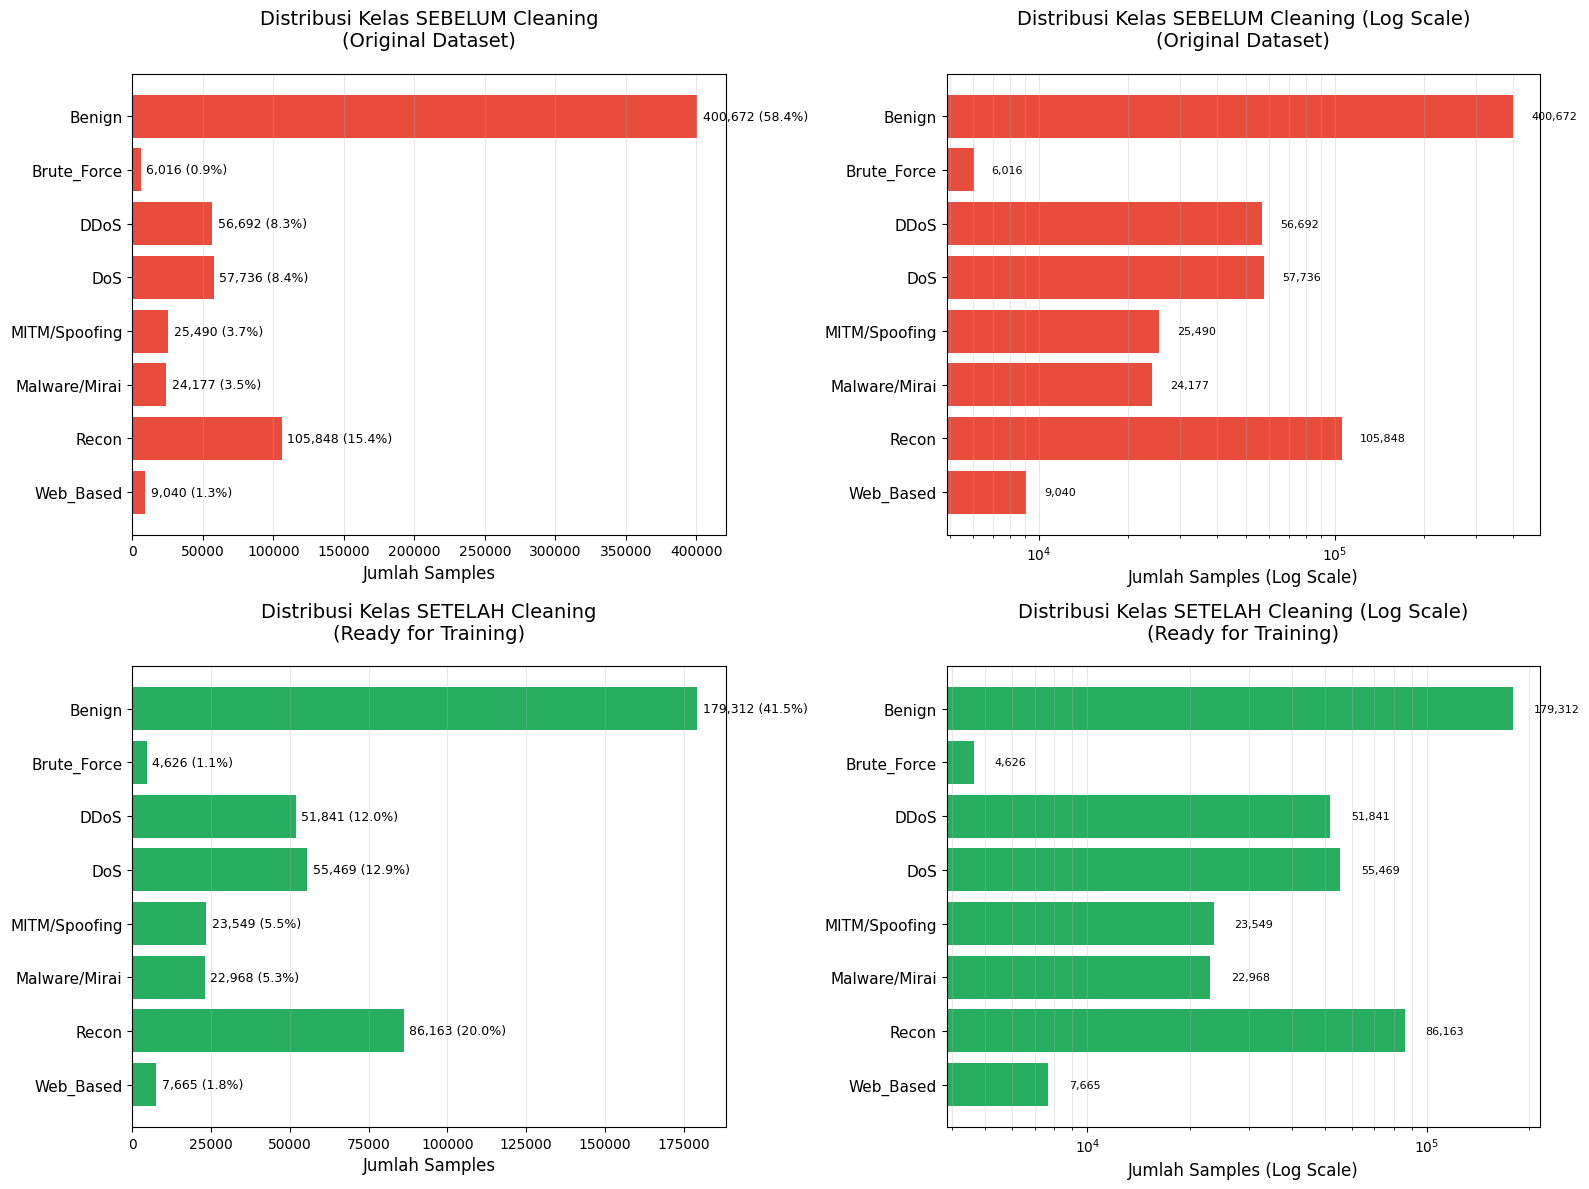


  Visualization saved to: /content/drive/My Drive/CICIIoT2025/Baseline8Multiclass/EDA_Results/


1360

In [ ]:
# Reconstruct after cleaning distribution dari train+test
y_all = np.concatenate([y_train, y_test])
y_decoded = [le.inverse_transform([label])[0] for label in y_all]
class_counts_after = pd.Series(y_decoded).value_counts().sort_index()

print(f"\n  Creating visualization...")

# Create comparison plot
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ========== SUBPLOT 1: BEFORE (Normal Scale) ==========
ax1 = axes[0, 0]
bars1 = ax1.barh(range(len(class_counts_before)), class_counts_before.values, color='#e74c3c')
ax1.set_yticks(range(len(class_counts_before)))
ax1.set_yticklabels(class_counts_before.index, fontsize=11)
ax1.set_xlabel('Jumlah Samples', fontsize=12)
ax1.set_title('Distribusi Kelas SEBELUM Cleaning\n(Original Dataset)',
              fontsize=14, pad=20)
ax1.grid(axis='x', alpha=0.3)
ax1.invert_yaxis()

for i, (bar, count) in enumerate(zip(bars1, class_counts_before.values)):
    width = bar.get_width()
    percentage = count / len(df_original) * 100
    ax1.text(width + max(class_counts_before.values)*0.01,
             bar.get_y() + bar.get_height()/2,
             f'{count:,} ({percentage:.1f}%)',
             va='center', fontsize=9)

# ========== SUBPLOT 2: BEFORE (Log Scale) ==========
ax2 = axes[0, 1]
bars2 = ax2.barh(range(len(class_counts_before)), class_counts_before.values, color='#e74c3c')
ax2.set_yticks(range(len(class_counts_before)))
ax2.set_yticklabels(class_counts_before.index, fontsize=11)
ax2.set_xlabel('Jumlah Samples (Log Scale)', fontsize=12)
ax2.set_xscale('log')
ax2.set_title('Distribusi Kelas SEBELUM Cleaning (Log Scale)\n(Original Dataset)',
              fontsize=14, pad=20)
ax2.grid(axis='x', alpha=0.3, which='both')
ax2.invert_yaxis()

for i, (bar, count) in enumerate(zip(bars2, class_counts_before.values)):
    width = bar.get_width()
    ax2.text(width * 1.15,
             bar.get_y() + bar.get_height()/2,
             f'{count:,}',
             va='center', fontsize=8)

# ========== SUBPLOT 3: AFTER (Normal Scale) ==========
ax3 = axes[1, 0]
bars3 = ax3.barh(range(len(class_counts_after)), class_counts_after.values, color='#27ae60')
ax3.set_yticks(range(len(class_counts_after)))
ax3.set_yticklabels(class_counts_after.index, fontsize=11)
ax3.set_xlabel('Jumlah Samples', fontsize=12)
ax3.set_title('Distribusi Kelas SETELAH Cleaning\n(Ready for Training)',
              fontsize=14, pad=20)
ax3.grid(axis='x', alpha=0.3)
ax3.invert_yaxis()

for i, (bar, count) in enumerate(zip(bars3, class_counts_after.values)):
    width = bar.get_width()
    percentage = count / len(y_all) * 100
    ax3.text(width + max(class_counts_after.values)*0.01,
             bar.get_y() + bar.get_height()/2,
             f'{count:,} ({percentage:.1f}%)',
             va='center', fontsize=9)

# ========== SUBPLOT 4: AFTER (Log Scale) ==========
ax4 = axes[1, 1]
bars4 = ax4.barh(range(len(class_counts_after)), class_counts_after.values, color='#27ae60')
ax4.set_yticks(range(len(class_counts_after)))
ax4.set_yticklabels(class_counts_after.index, fontsize=11)
ax4.set_xlabel('Jumlah Samples (Log Scale)', fontsize=12)
ax4.set_xscale('log')
ax4.set_title('Distribusi Kelas SETELAH Cleaning (Log Scale)\n(Ready for Training)',
              fontsize=14, pad=20)
ax4.grid(axis='x', alpha=0.3, which='both')
ax4.invert_yaxis()

for i, (bar, count) in enumerate(zip(bars4, class_counts_after.values)):
    width = bar.get_width()
    ax4.text(width * 1.15,
             bar.get_y() + bar.get_height()/2,
             f'{count:,}',
             va='center', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, '1_class_distribution_comparison.png'),
            dpi=300, bbox_inches='tight')
plt.show()

print(f"\n  Visualization saved to: {EDA_DIR}")

# Cleanup
del df_original
gc.collect()

###**Comparison Table - Before vs After**

In [ ]:
print("\n  Creating comparison table...")

comparison_data = []
for category in class_counts_before.index:
    before_count = class_counts_before[category]
    after_count = class_counts_after.get(category, 0)
    removed = before_count - after_count
    removed_pct = (removed / before_count * 100) if before_count > 0 else 0

    comparison_data.append({
        'Category': category,
        'Before': before_count,
        'After': after_count,
        'Removed': removed,
        'Removed %': round(removed_pct, 2)
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('Removed', ascending=False)

print(f"\nComparison: Before vs After Cleaning")
print("="*70)
print(comparison_df.to_string(index=False))

print(f"\n[Overall Summary]")
print(f"  Total Before: {class_counts_before.sum():,}")
print(f"  Total After: {class_counts_after.sum():,}")
print(f"  Total Removed: {685671 - summary['total_samples_cleaned']:,} ({((685671 - summary['total_samples_cleaned'])/685671*100):.1f}%)")

# Save comparison
comparison_df.to_csv(os.path.join(EDA_DIR, 'class_comparison_before_after.csv'), index=False)
print(f"\n  Comparison table saved!")


  Creating comparison table...

Comparison: Before vs After Cleaning
     Category  Before  After  Removed  Removed %
       Benign  400672 179312   221360      55.25
        Recon  105848  86163    19685      18.60
         DDoS   56692  51841     4851       8.56
          DoS   57736  55469     2267       3.93
MITM/Spoofing   25490  23549     1941       7.61
  Brute_Force    6016   4626     1390      23.11
    Web_Based    9040   7665     1375      15.21
Malware/Mirai   24177  22968     1209       5.00

[Overall Summary]
  Total Before: 685,671
  Total After: 431,593
  Total Removed: 254,078 (37.1%)

  Comparison table saved!


###**Train vs Test Distribution**


  Creating train/test distribution comparison...


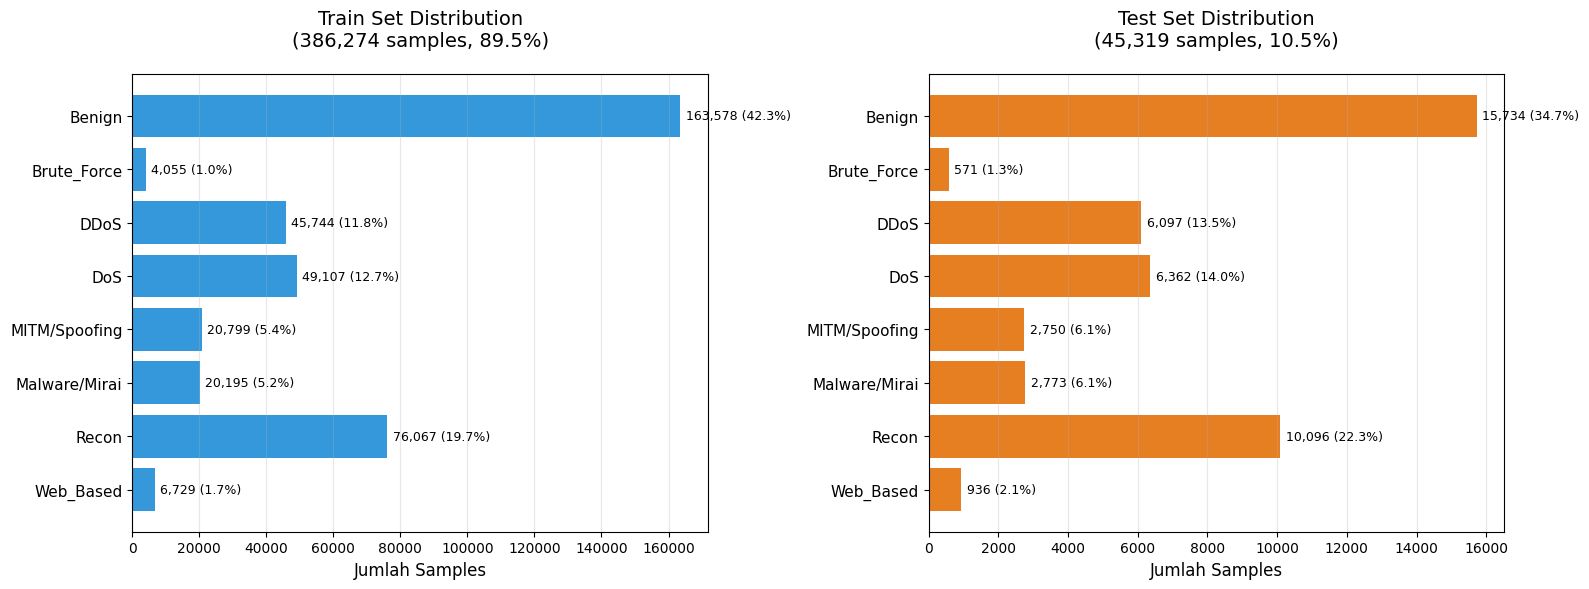

  Train/Test distribution saved!


In [ ]:
print("\n  Creating train/test distribution comparison...")

# Get train and test distributions
train_decoded = [le.inverse_transform([label])[0] for label in y_train]
test_decoded = [le.inverse_transform([label])[0] for label in y_test]

train_counts = pd.Series(train_decoded).value_counts().sort_index()
test_counts = pd.Series(test_decoded).value_counts().sort_index()

# Create side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Train distribution
ax1 = axes[0]
bars1 = ax1.barh(range(len(train_counts)), train_counts.values, color='#3498db')
ax1.set_yticks(range(len(train_counts)))
ax1.set_yticklabels(train_counts.index, fontsize=11)
ax1.set_xlabel('Jumlah Samples', fontsize=12)
ax1.set_title(f'Train Set Distribution\n({len(y_train):,} samples, {(len(y_train)/summary["total_samples_cleaned"]*100):.1f}%)',
              fontsize=14, pad=20)
ax1.grid(axis='x', alpha=0.3)
ax1.invert_yaxis()

for i, (bar, count) in enumerate(zip(bars1, train_counts.values)):
    width = bar.get_width()
    percentage = count / len(y_train) * 100
    ax1.text(width + max(train_counts.values)*0.01,
             bar.get_y() + bar.get_height()/2,
             f'{count:,} ({percentage:.1f}%)',
             va='center', fontsize=9)

# Test distribution
ax2 = axes[1]
bars2 = ax2.barh(range(len(test_counts)), test_counts.values, color='#e67e22')
ax2.set_yticks(range(len(test_counts)))
ax2.set_yticklabels(test_counts.index, fontsize=11)
ax2.set_xlabel('Jumlah Samples', fontsize=12)
ax2.set_title(f'Test Set Distribution\n({len(y_test):,} samples, {(len(y_test)/summary["total_samples_cleaned"]*100):.1f}%)',
              fontsize=14, pad=20)
ax2.grid(axis='x', alpha=0.3)
ax2.invert_yaxis()

for i, (bar, count) in enumerate(zip(bars2, test_counts.values)):
    width = bar.get_width()
    percentage = count / len(y_test) * 100
    ax2.text(width + max(test_counts.values)*0.01,
             bar.get_y() + bar.get_height()/2,
             f'{count:,} ({percentage:.1f}%)',
             va='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, '2_train_test_distribution.png'),
            dpi=300, bbox_inches='tight')
plt.show()

print(f"  Train/Test distribution saved!")

###**Dataset Statistics Summary**

In [ ]:
stats_summary = {
    'Dataset Info': {
        'Name': 'CICIIoT2025',
        'Original Samples': f"{685671:,}",
        'Cleaned Samples': f"{summary['total_samples_cleaned']:,}",
        'Removal Rate': f"{summary['removal_percentage']:.1f}%",
        'Number of Features': summary['jumlah_fitur'],
        'Number of Categories': summary['jumlah_kategori']
    },
    'Train/Test Split': {
        'Strategy': 'Time-based',
        'Train Windows': '1-8',
        'Test Windows': '9-10',
        'Train Samples': f"{summary['train_samples']:,} ({(summary['train_samples']/summary['total_samples_cleaned']*100):.1f}%)",
        'Test Samples': f"{summary['test_samples']:,} ({(summary['test_samples']/summary['total_samples_cleaned']*100):.1f}%)",
        'Data Leakage': 'None - Verified ✓'
    },
    'Class Balance': {
        'Imbalance Ratio': f"1:{summary['imbalance_ratio']:.0f}",
        'Majority Class': f"{summary['majority_class']} ({class_counts_after.max():,} samples)",
        'Minority Class': f"{summary['minority_class']} ({class_counts_after.min():,} samples)",
        'Balance Quality': 'Good (much better than CICIoT2023 1:965)'
    },
    'Data Quality': {
        'Missing Values': 'Handled ✓',
        'Infinite Values': 'Handled ✓',
        'All-Zero Rows': 'Removed ✓',
        'Exact Duplicates': 'Removed ✓',
        'Temporal Duplicates': 'Removed ✓'
    },
    'Preprocessing': {
        'Normalization': 'StandardScaler (mean≈0, std≈1)',
        'Label Encoding': 'LabelEncoder (0-7)',
        'Feature Selection': 'Manual (71 features)',
        'Memory Optimization': 'float32, int32'
    }
}

for section, items in stats_summary.items():
    print(f"\n{section}:")
    print("-"*70)
    for key, value in items.items():
        print(f"  {key:25s}: {value}")

print("\n" + "="*70)
print("EDA & VISUALISASI SELESAI!")
print("="*70)


Dataset Info:
----------------------------------------------------------------------
  Name                     : CICIIoT2025
  Original Samples         : 685,671
  Cleaned Samples          : 431,593
  Removal Rate             : 37.1%
  Number of Features       : 71
  Number of Categories     : 8

Train/Test Split:
----------------------------------------------------------------------
  Strategy                 : Time-based
  Train Windows            : 1-8
  Test Windows             : 9-10
  Train Samples            : 386,274 (89.5%)
  Test Samples             : 45,319 (10.5%)
  Data Leakage             : None - Verified ✓

Class Balance:
----------------------------------------------------------------------
  Imbalance Ratio          : 1:39
  Majority Class           : Benign (179,312 samples)
  Minority Class           : Brute_Force (4,626 samples)
  Balance Quality          : Good (much better than CICIoT2023 1:965)

Data Quality:
---------------------------------------------------

# **Langkah 2: Melatih Model Baseline (8 Kategori) Multiclass**

###**2.1 Definisi Fungsi Pembantu - Memory Management (Helper Functions)**

In [ ]:
def get_memory_usage():
    """Mendapatkan penggunaan RAM sistem"""
    memory = psutil.virtual_memory()
    used_gb = (memory.total - memory.available) / (1024**3)
    total_gb = memory.total / (1024**3)
    available_gb = memory.available / (1024**3)
    percent = memory.percent
    return used_gb, total_gb, available_gb, percent

def print_memory_status(stage=""):
    """Print status memori"""
    used, total, available, percent = get_memory_usage()
    print(f"\n[Memory Status - {stage}]")
    print(f"  Used: {used:.2f} GB / {total:.2f} GB ({percent:.1f}%)")
    print(f"  Available: {available:.2f} GB")

def clear_memory():
    """Bersihkan memory"""
    gc.collect()
    print("  Memory cleared")

print(" Memory management functions defined!")

 Memory management functions defined!


###**2.2 Definisi Fungsi Evaluasi Model**

In [ ]:
def evaluate_model(y_true, y_pred, model_name, training_time):
    """
    Fungsi untuk evaluasi model dengan berbagai metrik

    Parameters:
    -----------
    y_true : array-like
        True labels
    y_pred : array-like
        Predicted labels
    model_name : str
        Nama model
    training_time : float
        Waktu training dalam detik

    Returns:
    --------
    results : dict
        Dictionary berisi semua metrik evaluasi
    cm : array
        Confusion matrix
    report : dict
        Classification report detail per class
    """

    # Calculate all metrics
    results = {
        'model_name': model_name,
        'dataset_type': 'Full',
        'training_time_seconds': training_time,

        # Accuracy
        'accuracy': accuracy_score(y_true, y_pred),

        # Precision (3 averaging methods)
        'precision_macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'precision_weighted': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'precision_micro': precision_score(y_true, y_pred, average='micro', zero_division=0),

        # Recall (3 averaging methods)
        'recall_macro': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'recall_weighted': recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'recall_micro': recall_score(y_true, y_pred, average='micro', zero_division=0),

        # F1-Score (3 averaging methods)
        'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_weighted': f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'f1_micro': f1_score(y_true, y_pred, average='micro', zero_division=0),

        # Matthews Correlation Coefficient
        'mcc': matthews_corrcoef(y_true, y_pred)
    }

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    # Classification Report (detail per class)
    class_names = le.classes_
    report = classification_report(
        y_true, y_pred,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    return results, cm, report

print("evaluate_model() function defined!")

evaluate_model() function defined!


###**2.3 Definisi Fungsi Print Results**

In [ ]:
def print_results(results):
    """
    Print hasil evaluasi dengan format yang rapi

    Parameters:
    -----------
    results : dict
        Dictionary hasil evaluasi dari evaluate_model()
    """
    print(f"\n{'='*70}")
    print(f"HASIL EVALUASI: {results['model_name']} ({results['dataset_type']})")
    print(f"{'='*70}")
    print(f"Waktu Training: {results['training_time_seconds']:.2f} detik ({results['training_time_seconds']/60:.2f} menit)")

    print(f"\nMetrik Utama:")
    print(f"  Accuracy          : {results['accuracy']:.4f}")

    print(f"\nPrecision:")
    print(f"  Macro             : {results['precision_macro']:.4f}")
    print(f"  Weighted          : {results['precision_weighted']:.4f}")
    print(f"  Micro             : {results['precision_micro']:.4f}")

    print(f"\nRecall:")
    print(f"  Macro             : {results['recall_macro']:.4f}")
    print(f"  Weighted          : {results['recall_weighted']:.4f}")
    print(f"  Micro             : {results['recall_micro']:.4f}")

    print(f"\nF1-Score:")
    print(f"  Macro             : {results['f1_macro']:.4f}")
    print(f"  Weighted          : {results['f1_weighted']:.4f}")
    print(f"  Micro             : {results['f1_micro']:.4f}")

    print(f"\nMCC                 : {results['mcc']:.4f}")
    print(f"{'='*70}")

print("print_results() function defined!")

print_results() function defined!


###**2.4 Definisi Fungsi Print Detailed Report**

In [ ]:
def print_detailed_report(y_true, y_pred, model_name, label_encoder):
    """
    Print detailed classification report per category dengan format tabel

    Parameters:
    -----------
    y_true : array-like
        True labels
    y_pred : array-like
        Predicted labels
    model_name : str
        Nama model
    label_encoder : LabelEncoder
        Label encoder yang digunakan

    Returns:
    --------
    report_dict : dict
        Dictionary classification report
    """
    print("\n" + "="*80)
    print(f"DETAILED CLASSIFICATION REPORT: {model_name}")
    print("="*80)

    # Get category names
    target_names = label_encoder.classes_

    # Generate classification report
    report = classification_report(
        y_true,
        y_pred,
        target_names=target_names,
        digits=4,
        zero_division=0
    )

    print("\n" + report)

    # Calculate overall accuracy
    accuracy = accuracy_score(y_true, y_pred)
    print(f"\nConfirmed Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

    # Parse report to dictionary
    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=target_names,
        output_dict=True,
        zero_division=0
    )

    # Create detailed table view
    print("\n" + "="*80)
    print(f"PER-CATEGORY METRICS (Table Format)")
    print("="*80)
    print(f"{'Category':<15} {'Precision':>12} {'Recall':>12} {'F1-Score':>12} {'Support':>12}")
    print("-"*80)

    # Print each category
    for category in target_names:
        if category in report_dict:
            p = report_dict[category]['precision']
            r = report_dict[category]['recall']
            f1 = report_dict[category]['f1-score']
            support = int(report_dict[category]['support'])
            print(f"{category:<15} {p:>12.4f} {r:>12.4f} {f1:>12.4f} {support:>12,}")

    print("-"*80)

    # Print averages
    print(f"{'Macro Avg':<15} {report_dict['macro avg']['precision']:>12.4f} "
          f"{report_dict['macro avg']['recall']:>12.4f} "
          f"{report_dict['macro avg']['f1-score']:>12.4f} "
          f"{int(report_dict['macro avg']['support']):>12,}")

    print(f"{'Weighted Avg':<15} {report_dict['weighted avg']['precision']:>12.4f} "
          f"{report_dict['weighted avg']['recall']:>12.4f} "
          f"{report_dict['weighted avg']['f1-score']:>12.4f} "
          f"{int(report_dict['weighted avg']['support']):>12,}")

    print("="*80)

    return report_dict

print("print_detailed_report() function defined!")

print_detailed_report() function defined!


In [ ]:
# Inisialisasi List untuk Menyimpan Hasil
all_results = []
print("\n All helper functions ready!")
print("Results storage initialized!")


 All helper functions ready!
Results storage initialized!


###**2.5 Load Kembali Hasil Pre-Processing Data**

In [ ]:
print_memory_status("Sebelum Load Data")

print("\nMemuat data terproses dari Google Drive...")

# Load data
X_train = np.load(os.path.join(PROCESSED_DIR, 'X_train.npy'))
X_test = np.load(os.path.join(PROCESSED_DIR, 'X_test.npy'))
y_train = np.load(os.path.join(PROCESSED_DIR, 'y_train.npy'))
y_test = np.load(os.path.join(PROCESSED_DIR, 'y_test.npy'))

# Load label encoder
with open(os.path.join(PROCESSED_DIR, 'label_encoder.pkl'), 'rb') as f:
    le = pickle.load(f)

# Load feature names
with open(os.path.join(PROCESSED_DIR, 'feature_names.json'), 'r') as f:
    feature_names = json.load(f)

print(f"\nData dimuat:")
print(f"  - X_train shape: {X_train.shape}")
print(f"  - X_test shape: {X_test.shape}")
print(f"  - y_train shape: {y_train.shape}")
print(f"  - y_test shape: {y_test.shape}")
print(f"  - Jumlah kategori: {len(np.unique(y_train))}")
print(f"  - Jumlah fitur: {len(feature_names)}")

print(f"\n  Kategori: {le.classes_}")

print_memory_status("Setelah Load Data")


[Memory Status - Sebelum Load Data]
  Used: 2.07 GB / 12.67 GB (16.3%)
  Available: 10.60 GB

Memuat data terproses dari Google Drive...

Data dimuat:
  - X_train shape: (386274, 71)
  - X_test shape: (45319, 71)
  - y_train shape: (386274,)
  - y_test shape: (45319,)
  - Jumlah kategori: 8
  - Jumlah fitur: 71

  Kategori: ['Benign' 'Brute_Force' 'DDoS' 'DoS' 'MITM/Spoofing' 'Malware/Mirai'
 'Recon' 'Web_Based']

[Memory Status - Setelah Load Data]
  Used: 2.30 GB / 12.67 GB (18.1%)
  Available: 10.37 GB


###**2.6 Training Random Forest**

In [ ]:
print_memory_status("Sebelum Training RF")

start_time = time.time()

# Initialize Random Forest dengan parameter yang disesuaikan untuk dataset CICIIoT2025
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,           # Lebih shallow dari CICIoT2023
    min_samples_split=5,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("Mulai training Random Forest...")
rf_model.fit(X_train, y_train)

rf_time = time.time() - start_time

print(f"\nTraining selesai dalam {rf_time:.2f} detik ({rf_time/60:.2f} menit)")

print("\nMelakukan prediksi pada test set...")
y_pred_rf = rf_model.predict(X_test)

print(" Prediksi selesai!")

print_memory_status("Setelah Training RF")


[Memory Status - Sebelum Training RF]
  Used: 2.55 GB / 12.67 GB (20.1%)
  Available: 10.12 GB
Mulai training Random Forest...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:   36.7s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  1.6min finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.1s



Training selesai dalam 94.82 detik (1.58 menit)

Melakukan prediksi pada test set...
 Prediksi selesai!

[Memory Status - Setelah Training RF]
  Used: 2.55 GB / 12.67 GB (20.1%)
  Available: 10.12 GB


[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.2s finished


In [ ]:
print("\nEvaluasi Random Forest...")

# Evaluasi standar
rf_results, rf_cm, rf_report = evaluate_model(
    y_test, y_pred_rf, "Random Forest", rf_time
)

# Print hasil standar
print_results(rf_results)

# Print detailed report per category
rf_detailed = print_detailed_report(y_test, y_pred_rf, "Random Forest", le)

# Simpan ke all_results
all_results.append(rf_results)

# Simpan model dan hasil
print("\nMenyimpan model Random Forest...")
with open(os.path.join(MODELS_DIR, 'baseline_rf.pkl'), 'wb') as f:
    pickle.dump(rf_model, f)

np.save(os.path.join(RESULTS_DIR, 'cm_rf.npy'), rf_cm)

with open(os.path.join(RESULTS_DIR, 'report_rf.json'), 'w') as f:
    json.dump(rf_report, f, indent=4)

print("Model dan hasil Random Forest tersimpan!")

# Clear memory
del y_pred_rf
clear_memory()

print_memory_status("Setelah Cleanup RF")


Evaluasi Random Forest...

HASIL EVALUASI: Random Forest (Full)
Waktu Training: 94.82 detik (1.58 menit)

Metrik Utama:
  Accuracy          : 0.9924

Precision:
  Macro             : 0.9949
  Weighted          : 0.9925
  Micro             : 0.9924

Recall:
  Macro             : 0.9932
  Weighted          : 0.9924
  Micro             : 0.9924

F1-Score:
  Macro             : 0.9940
  Weighted          : 0.9924
  Micro             : 0.9924

MCC                 : 0.9903

DETAILED CLASSIFICATION REPORT: Random Forest

               precision    recall  f1-score   support

       Benign     0.9853    0.9999    0.9926     15734
  Brute_Force     0.9983    1.0000    0.9991       571
         DDoS     0.9997    0.9867    0.9931      6097
          DoS     0.9916    0.9961    0.9938      6362
MITM/Spoofing     0.9895    0.9985    0.9940      2750
Malware/Mirai     0.9964    0.9877    0.9920      2773
        Recon     0.9985    0.9807    0.9895     10096
    Web_Based     1.0000    0.9957    

###**2.7 Training XGBoost**

In [ ]:
print_memory_status("Sebelum Training XGBoost")

start_time = time.time()

# Initialize XGBoost dengan parameter yang disesuaikan untuk dataset CICIIoT2025
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=8,                    # Lebih shallow dari CICIoT2023 (10)
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softmax',
    num_class=len(np.unique(y_train)),  # 8 kategori
    eval_metric='mlogloss',
    tree_method='hist',             # Coba GPU dulu
    device='cuda',                  # GPU support
    random_state=42,
    n_jobs=-1
)

print("Mulai training XGBoost...")
print("(Mencoba menggunakan GPU, akan fallback ke CPU jika tidak tersedia)")

try:
    xgb_model.fit(
        X_train,
        y_train,
        verbose=True
    )
except Exception as e:
    print(f"\n GPU training failed: {e}")
    print("Switching to CPU...")

    # Fallback ke CPU
    xgb_model = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=8,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='multi:softmax',
        num_class=len(np.unique(y_train)),
        eval_metric='mlogloss',
        tree_method='hist',
        device='cpu',               # CPU fallback
        random_state=42,
        n_jobs=-1
    )

    xgb_model.fit(
        X_train,
        y_train,
        verbose=True
    )

xgb_time = time.time() - start_time

print(f"\n Training selesai dalam {xgb_time:.2f} detik ({xgb_time/60:.2f} menit)")

print("\nMelakukan prediksi pada test set...")
y_pred_xgb = xgb_model.predict(X_test)

print(" Prediksi selesai!")

print_memory_status("Setelah Training XGBoost")


[Memory Status - Sebelum Training XGBoost]
  Used: 2.54 GB / 12.67 GB (20.1%)
  Available: 10.13 GB
Mulai training XGBoost...
(Mencoba menggunakan GPU, akan fallback ke CPU jika tidak tersedia)

 Training selesai dalam 11.20 detik (0.19 menit)

Melakukan prediksi pada test set...
 Prediksi selesai!

[Memory Status - Setelah Training XGBoost]
  Used: 2.77 GB / 12.67 GB (21.9%)
  Available: 9.90 GB


In [ ]:
print("\nEvaluasi XGBoost...")

# Evaluasi standar
xgb_results, xgb_cm, xgb_report = evaluate_model(
    y_test, y_pred_xgb, "XGBoost", xgb_time
)

# Print hasil standar
print_results(xgb_results)

# Print detailed report per category
xgb_detailed = print_detailed_report(y_test, y_pred_xgb, "XGBoost", le)

# Simpan ke all_results
all_results.append(xgb_results)

# Simpan model dan hasil
print("\nMenyimpan model XGBoost...")
xgb_model.save_model(os.path.join(MODELS_DIR, 'baseline_xgboost.json'))

np.save(os.path.join(RESULTS_DIR, 'cm_xgboost.npy'), xgb_cm)

with open(os.path.join(RESULTS_DIR, 'report_xgboost.json'), 'w') as f:
    json.dump(xgb_report, f, indent=4)

print(" Model dan hasil XGBoost tersimpan!")

# Clear memory
del y_pred_xgb
clear_memory()

print_memory_status("Setelah Cleanup XGBoost")


Evaluasi XGBoost...

HASIL EVALUASI: XGBoost (Full)
Waktu Training: 11.20 detik (0.19 menit)

Metrik Utama:
  Accuracy          : 0.9951

Precision:
  Macro             : 0.9969
  Weighted          : 0.9951
  Micro             : 0.9951

Recall:
  Macro             : 0.9958
  Weighted          : 0.9951
  Micro             : 0.9951

F1-Score:
  Macro             : 0.9964
  Weighted          : 0.9951
  Micro             : 0.9951

MCC                 : 0.9938

DETAILED CLASSIFICATION REPORT: XGBoost

               precision    recall  f1-score   support

       Benign     0.9915    0.9989    0.9952     15734
  Brute_Force     0.9983    1.0000    0.9991       571
         DDoS     0.9997    0.9913    0.9955      6097
          DoS     0.9937    0.9983    0.9960      6362
MITM/Spoofing     0.9964    0.9989    0.9976      2750
Malware/Mirai     0.9989    0.9942    0.9966      2773
        Recon     0.9969    0.9884    0.9926     10096
    Web_Based     1.0000    0.9968    0.9984       936



###**2.8 Training LightGBM**

In [ ]:
print_memory_status("Sebelum Training LightGBM")

# Callback untuk logging progress
class LightGBMCallback:
    def __init__(self, total_iterations):
        self.total_iterations = total_iterations
        self.current_iteration = 0
        self.start_time = time.time()

    def __call__(self, env):
        self.current_iteration += 1
        if self.current_iteration % 10 == 0 or self.current_iteration == self.total_iterations:
            progress = (self.current_iteration / self.total_iterations) * 100
            elapsed = time.time() - self.start_time
            used, total, available, percent = get_memory_usage()
            print(f"  Iteration {self.current_iteration}/{self.total_iterations} "
                  f"({progress:.1f}%) - "
                  f"Time: {elapsed:.1f}s - "
                  f"RAM: {percent:.1f}% used ({available:.1f} GB available)")

lgb_callback = LightGBMCallback(100)

start_time = time.time()

# Initialize LightGBM dengan parameter yang disesuaikan untuk dataset CICIIoT2025
lgb_model = lgb.LGBMClassifier(
    n_estimators=100,
    max_depth=8,                    # Lebih shallow dari CICIoT2023 (10)
    learning_rate=0.1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multiclass',
    num_class=len(np.unique(y_train)),  # 8 kategori
    device='gpu',                   # Coba GPU dulu
    random_state=42,
    n_jobs=-1,
    verbose=-1                      # Suppress default logging
)

print("Mulai training LightGBM...")
print("(Mencoba menggunakan GPU, akan fallback ke CPU jika tidak tersedia)")
print("\nProgress akan ditampilkan setiap 10 iterasi")

try:
    lgb_model.fit(
        X_train,
        y_train,
        callbacks=[lgb_callback]
    )
except Exception as e:
    print(f"\n GPU training failed: {e}")
    print("Switching to CPU...")

    # Fallback ke CPU
    lgb_model = lgb.LGBMClassifier(
        n_estimators=100,
        max_depth=8,
        learning_rate=0.1,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='multiclass',
        num_class=len(np.unique(y_train)),
        device='cpu',               # CPU fallback
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    # Reset callback
    lgb_callback = LightGBMCallback(100)

    lgb_model.fit(
        X_train,
        y_train,
        callbacks=[lgb_callback]
    )

lgb_time = time.time() - start_time

print(f"\nTraining selesai dalam {lgb_time:.2f} detik ({lgb_time/60:.2f} menit)")

print("\nMelakukan prediksi pada test set...")
y_pred_lgb = lgb_model.predict(X_test)

print("Prediksi selesai!")

print_memory_status("Setelah Training LightGBM")


[Memory Status - Sebelum Training LightGBM]
  Used: 3.02 GB / 12.67 GB (23.9%)
  Available: 9.65 GB
Mulai training LightGBM...
(Mencoba menggunakan GPU, akan fallback ke CPU jika tidak tersedia)

Progress akan ditampilkan setiap 10 iterasi
  Iteration 10/100 (10.0%) - Time: 4.2s - RAM: 24.4% used (9.6 GB available)
  Iteration 20/100 (20.0%) - Time: 8.5s - RAM: 24.6% used (9.6 GB available)
  Iteration 30/100 (30.0%) - Time: 10.6s - RAM: 24.6% used (9.6 GB available)
  Iteration 40/100 (40.0%) - Time: 12.6s - RAM: 24.6% used (9.6 GB available)
  Iteration 50/100 (50.0%) - Time: 14.7s - RAM: 24.6% used (9.6 GB available)
  Iteration 60/100 (60.0%) - Time: 16.8s - RAM: 24.6% used (9.6 GB available)
  Iteration 70/100 (70.0%) - Time: 20.7s - RAM: 24.5% used (9.6 GB available)
  Iteration 80/100 (80.0%) - Time: 23.2s - RAM: 24.6% used (9.6 GB available)
  Iteration 90/100 (90.0%) - Time: 25.3s - RAM: 24.6% used (9.6 GB available)

 GPU training failed: Check failed: (best_split_info.left_

In [ ]:
print("\nEvaluasi LightGBM...")

# Evaluasi standar
lgb_results, lgb_cm, lgb_report = evaluate_model(
    y_test, y_pred_lgb, "LightGBM", lgb_time
)

# Print hasil standar
print_results(lgb_results)

# Print detailed report per category
lgb_detailed = print_detailed_report(y_test, y_pred_lgb, "LightGBM", le)

# Simpan ke all_results
all_results.append(lgb_results)

# Simpan model dan hasil
print("\nMenyimpan model LightGBM...")
with open(os.path.join(MODELS_DIR, 'baseline_lightgbm.pkl'), 'wb') as f:
    pickle.dump(lgb_model, f)

np.save(os.path.join(RESULTS_DIR, 'cm_lightgbm.npy'), lgb_cm)

with open(os.path.join(RESULTS_DIR, 'report_lightgbm.json'), 'w') as f:
    json.dump(lgb_report, f, indent=4)

print(" Model dan hasil LightGBM tersimpan!")

# Clear memory
del y_pred_lgb
clear_memory()

print_memory_status("Setelah Cleanup LightGBM")


Evaluasi LightGBM...

HASIL EVALUASI: LightGBM (Full)
Waktu Training: 107.15 detik (1.79 menit)

Metrik Utama:
  Accuracy          : 0.9950

Precision:
  Macro             : 0.9968
  Weighted          : 0.9950
  Micro             : 0.9950

Recall:
  Macro             : 0.9905
  Weighted          : 0.9950
  Micro             : 0.9950

F1-Score:
  Macro             : 0.9936
  Weighted          : 0.9950
  Micro             : 0.9950

MCC                 : 0.9936

DETAILED CLASSIFICATION REPORT: LightGBM

               precision    recall  f1-score   support

       Benign     0.9921    0.9989    0.9955     15734
  Brute_Force     0.9982    0.9527    0.9749       571
         DDoS     0.9984    0.9926    0.9955      6097
          DoS     0.9939    0.9984    0.9962      6362
MITM/Spoofing     0.9971    0.9993    0.9982      2750
Malware/Mirai     0.9993    0.9953    0.9973      2773
        Recon     0.9958    0.9890    0.9924     10096
    Web_Based     1.0000    0.9979    0.9989       9

###**2.9 Training Deep Neural Network (DNN)**

In [ ]:
print_memory_status("Sebelum Training DNN")

# Clear memory sebelum training
clear_memory()

# Get number of features and classes
num_features = X_train.shape[1]
num_classes = len(np.unique(y_train))

print(f"\nParameter DNN:")
print(f"  - Input features: {num_features}")
print(f"  - Output classes: {num_classes}")
print(f"  - Train samples: {X_train.shape[0]:,}")

def create_dnn_model(num_features, num_classes):
    """
    Membuat arsitektur DNN untuk 8 Kategori CICIIoT2025
    """
    model = keras.Sequential([
        layers.Input(shape=(num_features,)),

        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.BatchNormalization(),

        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.BatchNormalization(),

        layers.Dense(32, activation='relu'),
        layers.Dropout(0.2),
        layers.BatchNormalization(),

        layers.Dense(16, activation='relu'),

        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Create model
dnn_model = create_dnn_model(num_features, num_classes)

print("\nArsitektur DNN:")
dnn_model.summary()

# Custom callback untuk logging memory
class MemoryLoggingCallback(keras.callbacks.Callback):
    def __init__(self, log_frequency=1):
        super().__init__()
        self.log_frequency = log_frequency
        self.start_time = None

    def on_train_begin(self, logs=None):
        self.start_time = time.time()
        print("\n✓ Training dimulai...")
        print_memory_status("Train Begin")

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.log_frequency == 0:
            elapsed = time.time() - self.start_time
            used, total, available, percent = get_memory_usage()
            print(f"\nEpoch {epoch + 1}:")
            print(f"  Loss: {logs.get('loss'):.4f} - Acc: {logs.get('accuracy'):.4f}")
            print(f"  Val Loss: {logs.get('val_loss'):.4f} - Val Acc: {logs.get('val_accuracy'):.4f}")
            print(f"  Time: {elapsed:.1f}s - RAM: {percent:.1f}% ({available:.1f} GB available)")

# Callbacks
checkpoint = ModelCheckpoint(
    os.path.join(CHECKPOINT_DIR, 'dnn_best.keras'),
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

memory_logger = MemoryLoggingCallback(log_frequency=1)

print("\nMulai training DNN...")
print("Parameters:")
print("  - Epochs: 50")
print("  - Batch size: 256")
print("  - Validation split: 10% (stratified from train)")
print("  - Early stopping patience: 5")

start_time = time.time()

try:
    history = dnn_model.fit(
        X_train, y_train,
        validation_split=0.1,
        epochs=50,
        batch_size=256,
        callbacks=[checkpoint, early_stopping, reduce_lr, memory_logger],
        verbose=0  # Suppress default output, pakai custom callback
    )

    dnn_time = time.time() - start_time

    print(f"\n Training selesai dalam {dnn_time:.2f} detik ({dnn_time/60:.2f} menit)")
    print_memory_status("Setelah Training DNN")

except Exception as e:
    print(f"\n Error saat training DNN: {e}")
    print("Jika error memory, coba kurangi batch_size atau epochs")
    raise


[Memory Status - Sebelum Training DNN]
  Used: 3.02 GB / 12.67 GB (23.8%)
  Available: 9.65 GB
  Memory cleared

Parameter DNN:
  - Input features: 71
  - Output classes: 8
  - Train samples: 386,274

Arsitektur DNN:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,112 (82.47 KB)

 Trainable params: 20,664 (80.72 KB)

 Non-trainable params: 448 (1.75 KB)


Mulai training DNN...
Parameters:
  - Epochs: 50
  - Batch size: 256
  - Validation split: 10% (stratified from train)
  - Early stopping patience: 5

✓ Training dimulai...

[Memory Status - Train Begin]
  Used: 3.30 GB / 12.67 GB (26.1%)
  Available: 9.37 GB

Epoch 1: val_loss improved from inf to 0.27138, saving model to /content/drive/My Drive/CICIIoT2025/Baseline8Multiclass/Checkpoints/dnn_best.keras

Epoch 1:
  Loss: 0.5595 - Acc: 0.8275
  Val Loss: 0.2714 - Val Acc: 0.9132
  Time: 15.5s - RAM: 24.9% (9.5 GB available)

Epoch 2: val_loss improved from 0.27138 to 0.17765, saving model to /content/drive/My Drive/CICIIoT2025/Baseline8Multiclass/Checkpoints/dnn_best.keras

Epoch 2:
  Loss: 0.3276 - Acc: 0.9020
  Val Loss: 0.1776 - Val Acc: 0.9450
  Time: 20.2s - RAM: 24.9% (9.5 GB available)

Epoch 3: val_loss improved from 0.17765 to 0.15598, saving model to /content/drive/My Drive/CICIIoT2025/Baseline8Multiclass/Checkpoints/dnn_best.keras

Epoch 3:
  Loss: 0.2608 - Acc: 0.9208
  Va

In [ ]:
print("\nMelakukan prediksi pada test set...")

# Prediksi
y_pred_dnn_proba = dnn_model.predict(X_test, batch_size=256, verbose=0)
y_pred_dnn = np.argmax(y_pred_dnn_proba, axis=1)

print(" Prediksi selesai!")

print("\nEvaluasi Deep Neural Network...")

# Evaluasi standar
dnn_results, dnn_cm, dnn_report = evaluate_model(
    y_test, y_pred_dnn, "Deep Neural Network", dnn_time
)

# Print hasil standar
print_results(dnn_results)

# Print detailed report per category
dnn_detailed = print_detailed_report(y_test, y_pred_dnn, "Deep Neural Network", le)

# Simpan ke all_results
all_results.append(dnn_results)

# Simpan model dan hasil
print("\nMenyimpan model DNN...")
dnn_model.save(os.path.join(MODELS_DIR, 'baseline_dnn.keras'))

np.save(os.path.join(RESULTS_DIR, 'cm_dnn.npy'), dnn_cm)

with open(os.path.join(RESULTS_DIR, 'report_dnn.json'), 'w') as f:
    json.dump(dnn_report, f, indent=4)

# Save training history
history_dict = {
    'loss': [float(x) for x in history.history['loss']],
    'accuracy': [float(x) for x in history.history['accuracy']],
    'val_loss': [float(x) for x in history.history['val_loss']],
    'val_accuracy': [float(x) for x in history.history['val_accuracy']]
}

with open(os.path.join(RESULTS_DIR, 'dnn_history.json'), 'w') as f:
    json.dump(history_dict, f, indent=4)

print(" Model dan hasil DNN tersimpan!")

# Clear memory
del y_pred_dnn_proba, y_pred_dnn
clear_memory()

print_memory_status("Setelah Cleanup DNN")


Melakukan prediksi pada test set...
 Prediksi selesai!

Evaluasi Deep Neural Network...

HASIL EVALUASI: Deep Neural Network (Full)
Waktu Training: 236.72 detik (3.95 menit)

Metrik Utama:
  Accuracy          : 0.9747

Precision:
  Macro             : 0.9695
  Weighted          : 0.9748
  Micro             : 0.9747

Recall:
  Macro             : 0.9595
  Weighted          : 0.9747
  Micro             : 0.9747

F1-Score:
  Macro             : 0.9642
  Weighted          : 0.9747
  Micro             : 0.9747

MCC                 : 0.9678

DETAILED CLASSIFICATION REPORT: Deep Neural Network

               precision    recall  f1-score   support

       Benign     0.9840    0.9962    0.9901     15734
  Brute_Force     0.9468    0.8722    0.9079       571
         DDoS     0.9557    0.9634    0.9596      6097
          DoS     0.9750    0.9398    0.9571      6362
MITM/Spoofing     0.9241    0.9611    0.9422      2750
Malware/Mirai     0.9904    0.9704    0.9803      2773
        Recon     

###**2.10 Perbandingan Hasil Semua Model**

In [ ]:
# Create comparison dataframe
comparison_df = pd.DataFrame(all_results)

# Sort by accuracy descending
comparison_df = comparison_df.sort_values('accuracy', ascending=False)

print("\n" + "="*70)
print("COMPREHENSIVE METRICS COMPARISON")
print("="*70)

print("\n", comparison_df.to_string(index=False))

# Save comparison
comparison_df.to_csv(
    os.path.join(RESULTS_DIR, 'baseline_comparison.csv'),
    index=False
)

print(f"\n Comparison table saved to: {RESULTS_DIR}")

# Verify no NaN values
print("\n" + "="*70)
print("VERIFICATION: Checking for NaN values...")
print("="*70)

nan_counts = comparison_df.isnull().sum()
if nan_counts.sum() == 0:
    print("   SUCCESS: No NaN values found!")
else:
    print("   WARNING: NaN values detected:")
    print(nan_counts[nan_counts > 0])

# Print best models per metric
print("\n" + "="*70)
print("MODEL TERBAIK PER METRIK")
print("="*70)

metrics_to_check = {
    'Accuracy': 'accuracy',
    'F1-Score (Macro)': 'f1_macro',
    'F1-Score (Weighted)': 'f1_weighted',
    'Precision (Macro)': 'precision_macro',
    'Recall (Macro)': 'recall_macro',
    'MCC': 'mcc'
}

for metric_name, metric_col in metrics_to_check.items():
    best_idx = comparison_df[metric_col].idxmax()
    best_row = comparison_df.loc[best_idx]
    print(f"\n{metric_name}:")
    print(f"  Model            : {best_row['model_name']}")
    print(f"  Score            : {best_row[metric_col]:.4f}")
    print(f"  Training Time    : {best_row['training_time_seconds']:.2f}s ({best_row['training_time_seconds']/60:.2f} min)")


COMPREHENSIVE METRICS COMPARISON

          model_name dataset_type  training_time_seconds  accuracy  precision_macro  precision_weighted  precision_micro  recall_macro  recall_weighted  recall_micro  f1_macro  f1_weighted  f1_micro      mcc
            XGBoost         Full              11.199870  0.995123         0.996925            0.995143         0.995123      0.995847         0.995123      0.995123  0.996378     0.995121  0.995123 0.993785
           LightGBM         Full             107.146287  0.994991         0.996838            0.995005         0.994991      0.990517         0.994991      0.994991  0.993606     0.994983  0.994991 0.993614
           LightGBM         Full              37.174346  0.994815         0.996510            0.994823         0.994815      0.990329         0.994815      0.994815  0.993345     0.994805  0.994815 0.993387
      Random Forest         Full              94.820435  0.992387         0.994902            0.992465         0.992387      0.993169   

In [ ]:
print("\n" + "="*70)
print("DETAILED METRICS TABLE")
print("="*70)

# Create detailed table with important metrics
detailed_metrics = comparison_df[[
    'model_name',
    'training_time_seconds',
    'accuracy',
    'precision_macro',
    'precision_weighted',
    'recall_macro',
    'recall_weighted',
    'f1_macro',
    'f1_weighted',
    'mcc'
]].copy()

# Rename columns for better readability
detailed_metrics.columns = [
    'Model',
    'Time (s)',
    'Accuracy',
    'Precision (Macro)',
    'Precision (Weighted)',
    'Recall (Macro)',
    'Recall (Weighted)',
    'F1 (Macro)',
    'F1 (Weighted)',
    'MCC'
]

# Format time
detailed_metrics['Time (s)'] = detailed_metrics['Time (s)'].apply(lambda x: f"{x:.2f}")

# Format metrics to 4 decimal places
for col in detailed_metrics.columns[2:]:
    detailed_metrics[col] = detailed_metrics[col].apply(lambda x: f"{x:.4f}")

print("\n", detailed_metrics.to_string(index=False))

# Save detailed metrics
detailed_metrics.to_csv(
    os.path.join(RESULTS_DIR, 'detailed_metrics.csv'),
    index=False
)

print(f"\n Detailed metrics saved!")


DETAILED METRICS TABLE

               Model Time (s) Accuracy Precision (Macro) Precision (Weighted) Recall (Macro) Recall (Weighted) F1 (Macro) F1 (Weighted)    MCC
            XGBoost    11.20   0.9951            0.9969               0.9951         0.9958            0.9951     0.9964        0.9951 0.9938
           LightGBM   107.15   0.9950            0.9968               0.9950         0.9905            0.9950     0.9936        0.9950 0.9936
           LightGBM    37.17   0.9948            0.9965               0.9948         0.9903            0.9948     0.9933        0.9948 0.9934
      Random Forest    94.82   0.9924            0.9949               0.9925         0.9932            0.9924     0.9940        0.9924 0.9903
Deep Neural Network   236.72   0.9747            0.9695               0.9748         0.9595            0.9747     0.9642        0.9747 0.9678

 Detailed metrics saved!



CREATING VISUAL COMPARISON


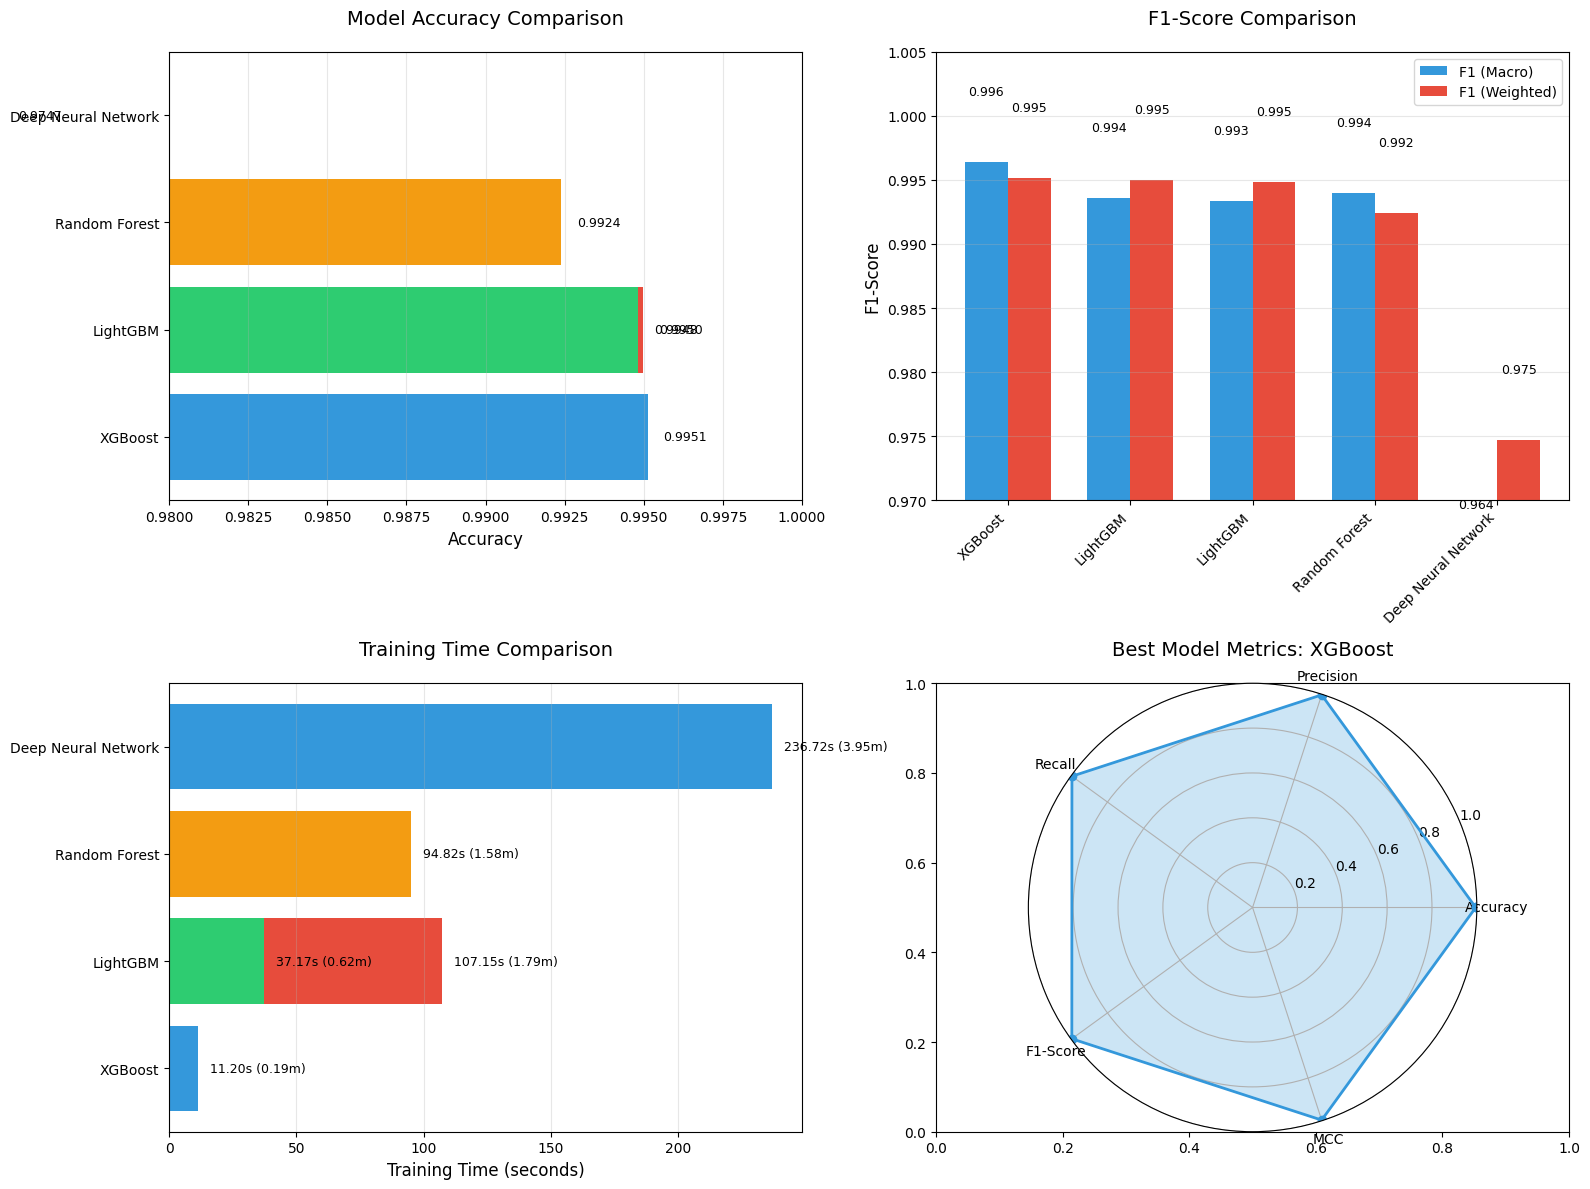

 Visual comparison saved!


In [ ]:
print("\n" + "="*70)
print("CREATING VISUAL COMPARISON")
print("="*70)

# Create comparison plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

models = comparison_df['model_name'].values
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

# Plot 1: Accuracy Comparison
ax1 = axes[0, 0]
bars1 = ax1.barh(models, comparison_df['accuracy'].values, color=colors)
ax1.set_xlabel('Accuracy', fontsize=12)
ax1.set_title('Model Accuracy Comparison', fontsize=14, pad=20)
ax1.set_xlim([0.98, 1.0])  # Focus on high accuracy range
ax1.grid(axis='x', alpha=0.3)

for i, (bar, val) in enumerate(zip(bars1, comparison_df['accuracy'].values)):
    ax1.text(val + 0.0005, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)

# Plot 2: F1-Score Comparison
ax2 = axes[0, 1]
x = np.arange(len(models))
width = 0.35

bars2a = ax2.bar(x - width/2, comparison_df['f1_macro'].values, width, label='F1 (Macro)', color='#3498db')
bars2b = ax2.bar(x + width/2, comparison_df['f1_weighted'].values, width, label='F1 (Weighted)', color='#e74c3c')

ax2.set_ylabel('F1-Score', fontsize=12)
ax2.set_title('F1-Score Comparison', fontsize=14, pad=20)
ax2.set_xticks(x)
ax2.set_xticklabels(models, rotation=45, ha='right', fontsize=10)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim([0.97, 1.005]) # Adjusted to prevent text overlap

for bar_group in [bars2a, bars2b]:
    for bar in bar_group:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.005, # Adjusted offset
                 f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# Plot 3: Training Time Comparison
ax3 = axes[1, 0]
bars3 = ax3.barh(models, comparison_df['training_time_seconds'].values, color=colors)
ax3.set_xlabel('Training Time (seconds)', fontsize=12)
ax3.set_title('Training Time Comparison', fontsize=14, pad=20)
ax3.grid(axis='x', alpha=0.3)

for i, (bar, val) in enumerate(zip(bars3, comparison_df['training_time_seconds'].values)):
    ax3.text(val + max(comparison_df['training_time_seconds'].values)*0.02,
             bar.get_y() + bar.get_height()/2,
             f'{val:.2f}s ({val/60:.2f}m)', va='center', fontsize=9)

# Plot 4: All Metrics Radar (for best model)
ax4 = axes[1, 1]

# Get best model (highest accuracy)
best_model_idx = comparison_df['accuracy'].idxmax()
best_model = comparison_df.loc[best_model_idx]

metrics_for_radar = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'mcc']
values = [best_model[m] for m in metrics_for_radar]
labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'MCC']

# Normalize MCC from [-1, 1] to [0, 1] for fair comparison
values_normalized = values.copy()
values_normalized[-1] = (values_normalized[-1] + 1) / 2  # MCC normalization

angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
values_normalized += values_normalized[:1]  # Complete the circle
angles += angles[:1]

ax4 = plt.subplot(2, 2, 4, projection='polar')
ax4.plot(angles, values_normalized, 'o-', linewidth=2, color='#3498db')
ax4.fill(angles, values_normalized, alpha=0.25, color='#3498db')
ax4.set_xticks(angles[:-1])
ax4.set_xticklabels(labels, fontsize=10)
ax4.set_ylim(0, 1)
ax4.set_title(f'Best Model Metrics: {best_model["model_name"]}',
              fontsize=14, pad=20)
ax4.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, '3_model_comparison.png'),
            dpi=300, bbox_inches='tight')
plt.show()

print(" Visual comparison saved!")

In [ ]:
print("\n" + "="*70)
print("FINAL SUMMARY & STATISTICS")
print("="*70)

final_summary = {
    'dataset': 'CICIIoT2025',
    'classification_type': 'Multiclass (8 Categories)',
    'total_models_trained': len(all_results),
    'best_model': {
        'name': comparison_df.loc[comparison_df['accuracy'].idxmax(), 'model_name'],
        'accuracy': float(comparison_df['accuracy'].max()),
        'f1_macro': float(comparison_df.loc[comparison_df['accuracy'].idxmax(), 'f1_macro']),
        'training_time': float(comparison_df.loc[comparison_df['accuracy'].idxmax(), 'training_time_seconds'])
    },
    'fastest_model': {
        'name': comparison_df.loc[comparison_df['training_time_seconds'].idxmin(), 'model_name'],
        'training_time': float(comparison_df['training_time_seconds'].min()),
        'accuracy': float(comparison_df.loc[comparison_df['training_time_seconds'].idxmin(), 'accuracy'])
    },
    'model_performance': {
        'average_accuracy': float(comparison_df['accuracy'].mean()),
        'std_accuracy': float(comparison_df['accuracy'].std()),
        'average_f1_macro': float(comparison_df['f1_macro'].mean()),
        'average_training_time': float(comparison_df['training_time_seconds'].mean())
    },
    'all_models': comparison_df.to_dict('records')
}

# Save final summary
with open(os.path.join(RESULTS_DIR, 'final_summary.json'), 'w') as f:
    json.dump(final_summary, f, indent=4)

print("\n[Best Model]")
print(f"  Model            : {final_summary['best_model']['name']}")
print(f"  Accuracy         : {final_summary['best_model']['accuracy']:.4f} ({final_summary['best_model']['accuracy']*100:.2f}%)")
print(f"  F1-Score (Macro) : {final_summary['best_model']['f1_macro']:.4f}")
print(f"  Training Time    : {final_summary['best_model']['training_time']:.2f}s")

print("\n[Fastest Model]")
print(f"  Model            : {final_summary['fastest_model']['name']}")
print(f"  Training Time    : {final_summary['fastest_model']['training_time']:.2f}s")
print(f"  Accuracy         : {final_summary['fastest_model']['accuracy']:.4f} ({final_summary['fastest_model']['accuracy']*100:.2f}%)")

print("\n[Overall Performance]")
print(f"  Average Accuracy : {final_summary['model_performance']['average_accuracy']:.4f}")
print(f"  Std Accuracy     : {final_summary['model_performance']['std_accuracy']:.4f}")
print(f"  Average F1 (Macro): {final_summary['model_performance']['average_f1_macro']:.4f}")
print(f"  Avg Training Time: {final_summary['model_performance']['average_training_time']:.2f}s")

print("\n" + "="*70)
print("BASELINE TRAINING COMPLETE!")
print("="*70)

print(f"\nSemua hasil tersimpan di:")
print(f"  - Models: {MODELS_DIR}")
print(f"  - Results: {RESULTS_DIR}")
print(f"  - EDA: {EDA_DIR}")
print(f"  - Checkpoints: {CHECKPOINT_DIR}")

print("\n TRAINING SELESAI - SEMUA MODEL BERHASIL!")


FINAL SUMMARY & STATISTICS

[Best Model]
  Model            : XGBoost
  Accuracy         : 0.9951 (99.51%)
  F1-Score (Macro) : 0.9964
  Training Time    : 11.20s

[Fastest Model]
  Model            : XGBoost
  Training Time    : 11.20s
  Accuracy         : 0.9951 (99.51%)

[Overall Performance]
  Average Accuracy : 0.9904
  Std Accuracy     : 0.0088
  Average F1 (Macro): 0.9883
  Avg Training Time: 97.41s

BASELINE TRAINING COMPLETE!

Semua hasil tersimpan di:
  - Models: /content/drive/My Drive/CICIIoT2025/Baseline8Multiclass/Models/
  - Results: /content/drive/My Drive/CICIIoT2025/Baseline8Multiclass/Results/
  - EDA: /content/drive/My Drive/CICIIoT2025/Baseline8Multiclass/EDA_Results/
  - Checkpoints: /content/drive/My Drive/CICIIoT2025/Baseline8Multiclass/Checkpoints/

 TRAINING SELESAI - SEMUA MODEL BERHASIL!


# **Random Split Comparasion (80-20)**

###**RECOVERY CELL 1: Setup Environment Setelah Runtime Terputus**

In [ ]:
print("="*70)
print("RECOVERY MODE: Setting Up Environment")
print("="*70)

# Import semua library yang diperlukan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import pickle
import psutil
import os
import gc
from datetime import datetime
import time
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

import xgboost as xgb
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    matthews_corrcoef, confusion_matrix, classification_report
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

print(" All libraries imported!")
print(f"  - TensorFlow: {tf.__version__}")
print(f"  - XGBoost: {xgb.__version__}")
print(f"  - LightGBM: {lgb.__version__}")

RECOVERY MODE: Setting Up Environment
 All libraries imported!
  - TensorFlow: 2.19.0
  - XGBoost: 3.1.2
  - LightGBM: 4.6.0


###**RECOVERY CELL 2: Mount Drive & Setup Paths**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Definisi path (SAMA seperti sebelumnya)
DATASET_PATH = '/content/drive/My Drive/Dataset/final_dataset.parquet'
PROCESSED_DIR = '/content/drive/My Drive/CICIIoT2025/Baseline8Multiclass/Processed_Data/'
MODELS_DIR = '/content/drive/My Drive/CICIIoT2025/Baseline8Multiclass/Models/'
RESULTS_DIR = '/content/drive/My Drive/CICIIoT2025/Baseline8Multiclass/Results/'
CHECKPOINT_DIR = '/content/drive/My Drive/CICIIoT2025/Baseline8Multiclass/Checkpoints/'
EDA_DIR = '/content/drive/My Drive/CICIIoT2025/Baseline8Multiclass/EDA_Results/'

print(" Google Drive mounted!")
print(" Paths configured!")

Mounted at /content/drive
 Google Drive mounted!
 Paths configured!


###**RECOVERY CELL 3: Recreate Helper Functions**

In [ ]:
def get_memory_usage():
    """Mendapatkan penggunaan RAM sistem"""
    memory = psutil.virtual_memory()
    used_gb = (memory.total - memory.available) / (1024**3)
    total_gb = memory.total / (1024**3)
    available_gb = memory.available / (1024**3)
    percent = memory.percent
    return used_gb, total_gb, available_gb, percent

def print_memory_status(stage=""):
    """Print status memori"""
    used, total, available, percent = get_memory_usage()
    print(f"\n[Memory Status - {stage}]")
    print(f"  Used: {used:.2f} GB / {total:.2f} GB ({percent:.1f}%)")
    print(f"  Available: {available:.2f} GB")

def clear_memory():
    """Bersihkan memory"""
    gc.collect()
    print("  Memory cleared")

def evaluate_model(y_true, y_pred, model_name, training_time):
    """Fungsi evaluasi model"""
    results = {
        'model_name': model_name,
        'dataset_type': 'Full',
        'training_time_seconds': training_time,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision_macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'precision_weighted': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'precision_micro': precision_score(y_true, y_pred, average='micro', zero_division=0),
        'recall_macro': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'recall_weighted': recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'recall_micro': recall_score(y_true, y_pred, average='micro', zero_division=0),
        'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_weighted': f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'f1_micro': f1_score(y_true, y_pred, average='micro', zero_division=0),
        'mcc': matthews_corrcoef(y_true, y_pred)
    }

    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, target_names=le.classes_,
                                   output_dict=True, zero_division=0)

    return results, cm, report

def print_results(results):
    """Print hasil evaluasi"""
    print(f"\n{'='*70}")
    print(f"HASIL EVALUASI: {results['model_name']} ({results['dataset_type']})")
    print(f"{'='*70}")
    print(f"Waktu Training: {results['training_time_seconds']:.2f} detik ({results['training_time_seconds']/60:.2f} menit)")
    print(f"\nMetrik Utama:")
    print(f"  Accuracy          : {results['accuracy']:.4f}")
    print(f"\nPrecision:")
    print(f"  Macro             : {results['precision_macro']:.4f}")
    print(f"  Weighted          : {results['precision_weighted']:.4f}")
    print(f"  Micro             : {results['precision_micro']:.4f}")
    print(f"\nRecall:")
    print(f"  Macro             : {results['recall_macro']:.4f}")
    print(f"  Weighted          : {results['recall_weighted']:.4f}")
    print(f"  Micro             : {results['recall_micro']:.4f}")
    print(f"\nF1-Score:")
    print(f"  Macro             : {results['f1_macro']:.4f}")
    print(f"  Weighted          : {results['f1_weighted']:.4f}")
    print(f"  Micro             : {results['f1_micro']:.4f}")
    print(f"\nMCC                 : {results['mcc']:.4f}")
    print(f"{'='*70}")

def print_detailed_report(y_true, y_pred, model_name, label_encoder):
    """Print detailed classification report"""
    print("\n" + "="*80)
    print(f"DETAILED CLASSIFICATION REPORT: {model_name}")
    print("="*80)

    target_names = label_encoder.classes_
    report = classification_report(y_true, y_pred, target_names=target_names,
                                   digits=4, zero_division=0)
    print("\n" + report)

    accuracy = accuracy_score(y_true, y_pred)
    print(f"\nConfirmed Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

    report_dict = classification_report(y_true, y_pred, target_names=target_names,
                                       output_dict=True, zero_division=0)

    print("\n" + "="*80)
    print(f"PER-CATEGORY METRICS (Table Format)")
    print("="*80)
    print(f"{'Category':<15} {'Precision':>12} {'Recall':>12} {'F1-Score':>12} {'Support':>12}")
    print("-"*80)

    for category in target_names:
        if category in report_dict:
            p = report_dict[category]['precision']
            r = report_dict[category]['recall']
            f1 = report_dict[category]['f1-score']
            support = int(report_dict[category]['support'])
            print(f"{category:<15} {p:>12.4f} {r:>12.4f} {f1:>12.4f} {support:>12,}")

    print("-"*80)
    print(f"{'Macro Avg':<15} {report_dict['macro avg']['precision']:>12.4f} "
          f"{report_dict['macro avg']['recall']:>12.4f} "
          f"{report_dict['macro avg']['f1-score']:>12.4f} "
          f"{int(report_dict['macro avg']['support']):>12,}")
    print(f"{'Weighted Avg':<15} {report_dict['weighted avg']['precision']:>12.4f} "
          f"{report_dict['weighted avg']['recall']:>12.4f} "
          f"{report_dict['weighted avg']['f1-score']:>12.4f} "
          f"{int(report_dict['weighted avg']['support']):>12,}")
    print("="*80)

    return report_dict

def create_dnn_model(num_features, num_classes):
    """Create DNN architecture"""
    model = keras.Sequential([
        layers.Input(shape=(num_features,)),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.BatchNormalization(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.BatchNormalization(),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.2),
        layers.BatchNormalization(),
        layers.Dense(16, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

class LightGBMCallback:
    def __init__(self, total_iterations):
        self.total_iterations = total_iterations
        self.current_iteration = 0
        self.start_time = time.time()

    def __call__(self, env):
        self.current_iteration += 1
        if self.current_iteration % 10 == 0 or self.current_iteration == self.total_iterations:
            progress = (self.current_iteration / self.total_iterations) * 100
            elapsed = time.time() - self.start_time
            used, total, available, percent = get_memory_usage()
            print(f"  Iteration {self.current_iteration}/{self.total_iterations} "
                  f"({progress:.1f}%) - Time: {elapsed:.1f}s - "
                  f"RAM: {percent:.1f}% ({available:.1f} GB available)")

class MemoryLoggingCallback(keras.callbacks.Callback):
    def __init__(self, log_frequency=1):
        super().__init__()
        self.log_frequency = log_frequency
        self.start_time = None

    def on_train_begin(self, logs=None):
        self.start_time = time.time()
        print("\n✓ Training dimulai...")
        print_memory_status("Train Begin")

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.log_frequency == 0:
            elapsed = time.time() - self.start_time
            used, total, available, percent = get_memory_usage()
            print(f"\nEpoch {epoch + 1}:")
            print(f"  Loss: {logs.get('loss'):.4f} - Acc: {logs.get('accuracy'):.4f}")
            print(f"  Val Loss: {logs.get('val_loss'):.4f} - Val Acc: {logs.get('val_accuracy'):.4f}")
            print(f"  Time: {elapsed:.1f}s - RAM: {percent:.1f}% ({available:.1f} GB available)")

print(" All helper functions recreated!")

 All helper functions recreated!


###**RECOVERY CELL 4: Load Processed Data (Time-based Split)**

In [ ]:
print("\n" + "="*70)
print("Loading Processed Data dari Google Drive...")
print("="*70)

# Load time-based split data
X_train = np.load(os.path.join(PROCESSED_DIR, 'X_train.npy'))
X_test = np.load(os.path.join(PROCESSED_DIR, 'X_test.npy'))
y_train = np.load(os.path.join(PROCESSED_DIR, 'y_train.npy'))
y_test = np.load(os.path.join(PROCESSED_DIR, 'y_test.npy'))

# Load label encoder
with open(os.path.join(PROCESSED_DIR, 'label_encoder.pkl'), 'rb') as f:
    le = pickle.load(f)

# Load feature names
with open(os.path.join(PROCESSED_DIR, 'feature_names.json'), 'r') as f:
    feature_names = json.load(f)

# Load preprocessing summary
with open(os.path.join(RESULTS_DIR, 'preprocessing_summary.json'), 'r') as f:
    summary = json.load(f)

print(f" Data loaded successfully!")
print(f"  - X_train: {X_train.shape}")
print(f"  - X_test: {X_test.shape}")
print(f"  - y_train: {y_train.shape}")
print(f"  - y_test: {y_test.shape}")
print(f"  - Features: {len(feature_names)}")
print(f"  - Categories: {le.classes_}")

print_memory_status("After Loading Data")


Loading Processed Data dari Google Drive...
 Data loaded successfully!
  - X_train: (386274, 71)
  - X_test: (45319, 71)
  - y_train: (386274,)
  - y_test: (45319,)
  - Features: 71
  - Categories: ['Benign' 'Brute_Force' 'DDoS' 'DoS' 'MITM/Spoofing' 'Malware/Mirai'
 'Recon' 'Web_Based']

[Memory Status - After Loading Data]
  Used: 2.29 GB / 12.67 GB (18.1%)
  Available: 10.38 GB


###**RECOVERY CELL 5: Verify Time-Based Models Exist (Optional)**

In [ ]:
print("\n" + "="*70)
print("Verifying Time-Based Split Models...")
print("="*70)

# Check if time-based models exist
models_exist = {
    'Random Forest': os.path.exists(os.path.join(MODELS_DIR, 'baseline_rf.pkl')),
    'XGBoost': os.path.exists(os.path.join(MODELS_DIR, 'baseline_xgboost.json')),
    'LightGBM': os.path.exists(os.path.join(MODELS_DIR, 'baseline_lightgbm.pkl')),
    'DNN': os.path.exists(os.path.join(MODELS_DIR, 'baseline_dnn.keras'))
}

print("\nTime-Based Split Models Status:")
for model_name, exists in models_exist.items():
    status = " EXISTS" if exists else "✗ MISSING"
    print(f"  {model_name:<20}: {status}")

all_exist = all(models_exist.values())

if all_exist:
    print("\n All time-based models found! Ready for random split comparison.")
else:
    print("\n Some time-based models are missing. You may need to retrain them first.")

# Load comparison results if exists
comparison_file = os.path.join(RESULTS_DIR, 'baseline_comparison.csv')
if os.path.exists(comparison_file):
    comparison_df_timebased = pd.read_csv(comparison_file)
    print("\n Time-based comparison results loaded:")
    print(comparison_df_timebased[['model_name', 'accuracy', 'f1_macro', 'training_time_seconds']])
else:
    print("\n Time-based comparison results not found.")


Verifying Time-Based Split Models...

Time-Based Split Models Status:
  Random Forest       :  EXISTS
  XGBoost             :  EXISTS
  LightGBM            :  EXISTS
  DNN                 :  EXISTS

 All time-based models found! Ready for random split comparison.

 Time-based comparison results loaded:
            model_name  accuracy  f1_macro  training_time_seconds
0              XGBoost  0.995123  0.996378              11.199870
1             LightGBM  0.994991  0.993606             107.146287
2             LightGBM  0.994815  0.993345              37.174346
3        Random Forest  0.992387  0.994007              94.820435
4  Deep Neural Network  0.974735  0.964181             236.722391


###**RECOVERY CELL 6: Initialize for Random Split Training**

In [ ]:
print("\n" + "="*70)
print("READY FOR RANDOM SPLIT TRAINING!")
print("="*70)

# Initialize results storage
all_results_random = []

print("\nRecovery complete! You can now proceed with:")
print("   - Load Data for Random Split")
print("   - Random Stratified Split")
print("   - Re-normalize Data")
print("   - Training Models with Random Split")

print_memory_status("Recovery Complete")


READY FOR RANDOM SPLIT TRAINING!

Recovery complete! You can now proceed with:
   - Load Data for Random Split
   - Random Stratified Split
   - Re-normalize Data
   - Training Models with Random Split

[Memory Status - Recovery Complete]
  Used: 2.31 GB / 12.67 GB (18.2%)
  Available: 10.37 GB


###**Load Data Original untuk Random Split**

In [ ]:
print("\nObjective:")
print("  Membandingkan performa model dengan strategi split berbeda:")
print("  - Time-based split (current): windows 1-8 vs 9-10")
print("  - Random stratified split (new): 80% vs 20%")

print("\n" + "-"*70)
print("1 Persiapan Data untuk Random Split")
print("-"*70)

print_memory_status("Before Random Split Preparation")

# Load processed data yang sudah di-normalize (kita akan re-split)
# Tapi kita perlu load ulang sebelum split untuk ensure fair comparison

print("\nLoading original processed data (before time-based split)...")

# Load data yang sudah di-clean tapi belum di-split
# Kita perlu reconstruct dari train + test
X_all = np.vstack([X_train, X_test])
y_all = np.concatenate([y_train, y_test])

print(f"Combined data loaded:")
print(f"  - Total samples: {X_all.shape[0]:,}")
print(f"  - Features: {X_all.shape[1]}")
print(f"  - Classes: {len(np.unique(y_all))}")

# Verify data integrity
assert X_all.shape[0] == len(y_all), "Mismatch between features and labels!"
assert X_all.shape[0] == summary['total_samples_cleaned'], "Data count mismatch!"

print("\nData integrity verified!")


Objective:
  Membandingkan performa model dengan strategi split berbeda:
  - Time-based split (current): windows 1-8 vs 9-10
  - Random stratified split (new): 80% vs 20%

----------------------------------------------------------------------
1 Persiapan Data untuk Random Split
----------------------------------------------------------------------

[Memory Status - Before Random Split Preparation]
  Used: 2.31 GB / 12.67 GB (18.2%)
  Available: 10.37 GB

Loading original processed data (before time-based split)...
Combined data loaded:
  - Total samples: 431,593
  - Features: 71
  - Classes: 8

Data integrity verified!


###**Random Stratified Split**

In [ ]:
print("\n2 Melakukan Random Stratified Split (80-20)")
print("-"*70)

# Gunakan stratified split untuk mempertahankan proporsi kelas
X_train_random, X_test_random, y_train_random, y_test_random = train_test_split(
    X_all,
    y_all,
    test_size=0.2,
    random_state=42,
    stratify=y_all  # IMPORTANT: stratified split
)

print(f"Random split complete!")
print(f"  - Train set: {X_train_random.shape[0]:,} rows ({(X_train_random.shape[0]/X_all.shape[0]*100):.1f}%)")
print(f"  - Test set: {X_test_random.shape[0]:,} rows ({(X_test_random.shape[0]/X_all.shape[0]*100):.1f}%)")

# Compare distributions
print(f"\nDistribusi Kelas - Random Split:")
print(f"\n  Train set:")
train_dist_random = pd.Series(y_train_random).value_counts().sort_index()
for idx in train_dist_random.index:
    class_name = le.inverse_transform([idx])[0]
    count = train_dist_random[idx]
    pct = (count / len(y_train_random)) * 100
    print(f"    {idx} ({class_name:12s}): {count:7,} ({pct:5.2f}%)")

print(f"\n  Test set:")
test_dist_random = pd.Series(y_test_random).value_counts().sort_index()
for idx in test_dist_random.index:
    class_name = le.inverse_transform([idx])[0]
    count = test_dist_random[idx]
    pct = (count / len(y_test_random)) * 100
    print(f"    {idx} ({class_name:12s}): {count:7,} ({pct:5.2f}%)")

# Compare with time-based split
print(f"\nComparison: Time-based vs Random Split")
print(f"  {'Metric':<25} {'Time-based':>15} {'Random':>15}")
print(f"  {'-'*55}")
print(f"  {'Train samples':<25} {len(y_train):>15,} {len(y_train_random):>15,}")
print(f"  {'Test samples':<25} {len(y_test):>15,} {len(y_test_random):>15,}")
print(f"  {'Train ratio':<25} {len(y_train)/len(y_all)*100:>14.1f}% {len(y_train_random)/len(y_all)*100:>14.1f}%")
print(f"  {'Test ratio':<25} {len(y_test)/len(y_all)*100:>14.1f}% {len(y_test_random)/len(y_all)*100:>14.1f}%")

print_memory_status("After Random Split")


2 Melakukan Random Stratified Split (80-20)
----------------------------------------------------------------------
Random split complete!
  - Train set: 345,274 rows (80.0%)
  - Test set: 86,319 rows (20.0%)

Distribusi Kelas - Random Split:

  Train set:
    0 (Benign      ): 143,450 (41.55%)
    1 (Brute_Force ):   3,701 ( 1.07%)
    2 (DDoS        ):  41,473 (12.01%)
    3 (DoS         ):  44,375 (12.85%)
    4 (MITM/Spoofing):  18,839 ( 5.46%)
    5 (Malware/Mirai):  18,374 ( 5.32%)
    6 (Recon       ):  68,930 (19.96%)
    7 (Web_Based   ):   6,132 ( 1.78%)

  Test set:
    0 (Benign      ):  35,862 (41.55%)
    1 (Brute_Force ):     925 ( 1.07%)
    2 (DDoS        ):  10,368 (12.01%)
    3 (DoS         ):  11,094 (12.85%)
    4 (MITM/Spoofing):   4,710 ( 5.46%)
    5 (Malware/Mirai):   4,594 ( 5.32%)
    6 (Recon       ):  17,233 (19.96%)
    7 (Web_Based   ):   1,533 ( 1.78%)

Comparison: Time-based vs Random Split
  Metric                         Time-based          Random
  

###**Re-normalize Data untuk Random Split**

In [ ]:
print("\n3 Re-normalize Data untuk Random Split")
print("-"*70)

# IMPORTANT: Fit new scaler pada random train set
scaler_random = StandardScaler()

X_train_random_scaled = scaler_random.fit_transform(X_train_random)
X_test_random_scaled = scaler_random.transform(X_test_random)

print(f"Data normalized dengan StandardScaler (fitted on random train)")
print(f"  - Mean: {X_train_random_scaled.mean():.10f}")
print(f"  - Std: {X_train_random_scaled.std():.10f}")

# Save random split data
print("\nMenyimpan random split data...")

np.save(os.path.join(PROCESSED_DIR, 'X_train_random.npy'), X_train_random_scaled)
np.save(os.path.join(PROCESSED_DIR, 'X_test_random.npy'), X_test_random_scaled)
np.save(os.path.join(PROCESSED_DIR, 'y_train_random.npy'), y_train_random)
np.save(os.path.join(PROCESSED_DIR, 'y_test_random.npy'), y_test_random)

with open(os.path.join(PROCESSED_DIR, 'scaler_random.pkl'), 'wb') as f:
    pickle.dump(scaler_random, f)

print("Random split data tersimpan!")


3 Re-normalize Data untuk Random Split
----------------------------------------------------------------------
Data normalized dengan StandardScaler (fitted on random train)
  - Mean: 0.0000000000
  - Std: 1.0000000000

Menyimpan random split data...
Random split data tersimpan!


###**Initialize Results Storage untuk Random Split**

In [ ]:
print("\n4 Training Models dengan Random Split")
print("-"*70)

# Initialize list untuk menyimpan hasil random split
all_results_random = []

print("Ready to train models on random split!")


4 Training Models dengan Random Split
----------------------------------------------------------------------
Ready to train models on random split!


###**Training Random Forest (Random Split)**

In [ ]:
print("\nTraining Random Forest (Random Split)")
print("-"*70)

print_memory_status("Before RF Random")

start_time = time.time()

rf_model_random = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("Mulai training Random Forest (Random Split)...")
rf_model_random.fit(X_train_random_scaled, y_train_random)

rf_time_random = time.time() - start_time

print(f"\nTraining selesai dalam {rf_time_random:.2f} detik ({rf_time_random/60:.2f} menit)")

print("\nMelakukan prediksi...")
y_pred_rf_random = rf_model_random.predict(X_test_random_scaled)

# Evaluasi
rf_results_random, rf_cm_random, rf_report_random = evaluate_model(
    y_test_random, y_pred_rf_random, "Random Forest (Random Split)", rf_time_random
)

print_results(rf_results_random)
rf_detailed_random = print_detailed_report(y_test_random, y_pred_rf_random,
                                           "Random Forest (Random Split)", le)

all_results_random.append(rf_results_random)

# Save
with open(os.path.join(MODELS_DIR, 'baseline_rf_random.pkl'), 'wb') as f:
    pickle.dump(rf_model_random, f)

np.save(os.path.join(RESULTS_DIR, 'cm_rf_random.npy'), rf_cm_random)

with open(os.path.join(RESULTS_DIR, 'report_rf_random.json'), 'w') as f:
    json.dump(rf_report_random, f, indent=4)

del y_pred_rf_random
clear_memory()

print_memory_status("After RF Random")


Training Random Forest (Random Split)
----------------------------------------------------------------------

[Memory Status - Before RF Random]
  Used: 3.01 GB / 12.67 GB (23.8%)
  Available: 9.66 GB
Mulai training Random Forest (Random Split)...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  2.4min finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.



Training selesai dalam 145.66 detik (2.43 menit)

Melakukan prediksi...


[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.5s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    1.3s finished



HASIL EVALUASI: Random Forest (Random Split) (Full)
Waktu Training: 145.66 detik (2.43 menit)

Metrik Utama:
  Accuracy          : 0.9812

Precision:
  Macro             : 0.9870
  Weighted          : 0.9816
  Micro             : 0.9812

Recall:
  Macro             : 0.9759
  Weighted          : 0.9812
  Micro             : 0.9812

F1-Score:
  Macro             : 0.9813
  Weighted          : 0.9812
  Micro             : 0.9812

MCC                 : 0.9750

DETAILED CLASSIFICATION REPORT: Random Forest (Random Split)

               precision    recall  f1-score   support

       Benign     0.9684    0.9991    0.9835     35862
  Brute_Force     0.9911    0.9643    0.9775       925
         DDoS     0.9974    0.9632    0.9800     10368
          DoS     0.9890    0.9841    0.9866     11094
MITM/Spoofing     0.9620    0.9781    0.9700      4710
Malware/Mirai     0.9931    0.9689    0.9808      4594
        Recon     0.9948    0.9569    0.9755     17233
    Web_Based     1.0000    0.9922

###**Training XGBoost (Random Split)**

In [ ]:
print_memory_status("Before XGBoost Random")

start_time = time.time()

xgb_model_random = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softmax',
    num_class=len(np.unique(y_train_random)),
    eval_metric='mlogloss',
    tree_method='hist',
    device='cuda',
    random_state=42,
    n_jobs=-1
)

print("Mulai training XGBoost (Random Split)...")

try:
    xgb_model_random.fit(X_train_random_scaled, y_train_random, verbose=True)
except Exception as e:
    print(f"\nGPU training failed: {e}")
    print("Switching to CPU...")
    xgb_model_random.set_params(device='cpu')
    xgb_model_random.fit(X_train_random_scaled, y_train_random, verbose=True)

xgb_time_random = time.time() - start_time

print(f"\nTraining selesai dalam {xgb_time_random:.2f} detik ({xgb_time_random/60:.2f} menit)")

print("\nMelakukan prediksi...")
y_pred_xgb_random = xgb_model_random.predict(X_test_random_scaled)

# Evaluasi
xgb_results_random, xgb_cm_random, xgb_report_random = evaluate_model(
    y_test_random, y_pred_xgb_random, "XGBoost (Random Split)", xgb_time_random
)

print_results(xgb_results_random)
xgb_detailed_random = print_detailed_report(y_test_random, y_pred_xgb_random,
                                            "XGBoost (Random Split)", le)

all_results_random.append(xgb_results_random)

# Save
xgb_model_random.save_model(os.path.join(MODELS_DIR, 'baseline_xgboost_random.json'))

np.save(os.path.join(RESULTS_DIR, 'cm_xgboost_random.npy'), xgb_cm_random)

with open(os.path.join(RESULTS_DIR, 'report_xgboost_random.json'), 'w') as f:
    json.dump(xgb_report_random, f, indent=4)

del y_pred_xgb_random
clear_memory()

print_memory_status("After XGBoost Random")


[Memory Status - Before XGBoost Random]
  Used: 3.25 GB / 12.67 GB (25.6%)
  Available: 9.42 GB
Mulai training XGBoost (Random Split)...

Training selesai dalam 18.41 detik (0.31 menit)

Melakukan prediksi...

HASIL EVALUASI: XGBoost (Random Split) (Full)
Waktu Training: 18.41 detik (0.31 menit)

Metrik Utama:
  Accuracy          : 0.9858

Precision:
  Macro             : 0.9897
  Weighted          : 0.9859
  Micro             : 0.9858

Recall:
  Macro             : 0.9823
  Weighted          : 0.9858
  Micro             : 0.9858

F1-Score:
  Macro             : 0.9859
  Weighted          : 0.9858
  Micro             : 0.9858

MCC                 : 0.9811

DETAILED CLASSIFICATION REPORT: XGBoost (Random Split)

               precision    recall  f1-score   support

       Benign     0.9774    0.9985    0.9879     35862
  Brute_Force     0.9891    0.9784    0.9837       925
         DDoS     0.9961    0.9767    0.9863     10368
          DoS     0.9953    0.9867    0.9909     11094
MI

###**Training LightGBM (Random Split)**

In [ ]:
print_memory_status("Before LightGBM Random")

lgb_callback_random = LightGBMCallback(100)

start_time = time.time()

lgb_model_random = lgb.LGBMClassifier(
    n_estimators=100,
    max_depth=8,
    learning_rate=0.1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multiclass',
    num_class=len(np.unique(y_train_random)),
    device='gpu',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

print("Mulai training LightGBM (Random Split)...")
print("Progress akan ditampilkan setiap 10 iterasi")

try:
    lgb_model_random.fit(X_train_random_scaled, y_train_random,
                         callbacks=[lgb_callback_random])
except Exception as e:
    print(f"\nGPU training failed: {e}")
    print("Switching to CPU...")
    lgb_model_random.set_params(device='cpu')
    lgb_callback_random = LightGBMCallback(100)
    lgb_model_random.fit(X_train_random_scaled, y_train_random,
                         callbacks=[lgb_callback_random])

lgb_time_random = time.time() - start_time

print(f"\nTraining selesai dalam {lgb_time_random:.2f} detik ({lgb_time_random/60:.2f} menit)")

print("\nMelakukan prediksi...")
y_pred_lgb_random = lgb_model_random.predict(X_test_random_scaled)

# Evaluasi
lgb_results_random, lgb_cm_random, lgb_report_random = evaluate_model(
    y_test_random, y_pred_lgb_random, "LightGBM (Random Split)", lgb_time_random
)

print_results(lgb_results_random)
lgb_detailed_random = print_detailed_report(y_test_random, y_pred_lgb_random,
                                            "LightGBM (Random Split)", le)

all_results_random.append(lgb_results_random)

# Save
with open(os.path.join(MODELS_DIR, 'baseline_lightgbm_random.pkl'), 'wb') as f:
    pickle.dump(lgb_model_random, f)

np.save(os.path.join(RESULTS_DIR, 'cm_lightgbm_random.npy'), lgb_cm_random)

with open(os.path.join(RESULTS_DIR, 'report_lightgbm_random.json'), 'w') as f:
    json.dump(lgb_report_random, f, indent=4)

del y_pred_lgb_random
clear_memory()

print_memory_status("After LightGBM Random")


[Memory Status - Before LightGBM Random]
  Used: 3.63 GB / 12.67 GB (28.6%)
  Available: 9.04 GB
Mulai training LightGBM (Random Split)...
Progress akan ditampilkan setiap 10 iterasi
  Iteration 10/100 (10.0%) - Time: 20.6s - RAM: 32.2% (8.6 GB available)
  Iteration 20/100 (20.0%) - Time: 25.2s - RAM: 32.5% (8.6 GB available)
  Iteration 30/100 (30.0%) - Time: 31.6s - RAM: 33.2% (8.5 GB available)
  Iteration 40/100 (40.0%) - Time: 37.1s - RAM: 33.4% (8.4 GB available)
  Iteration 50/100 (50.0%) - Time: 47.0s - RAM: 34.3% (8.3 GB available)
  Iteration 60/100 (60.0%) - Time: 53.3s - RAM: 34.6% (8.3 GB available)
  Iteration 70/100 (70.0%) - Time: 55.4s - RAM: 34.6% (8.3 GB available)
  Iteration 80/100 (80.0%) - Time: 59.9s - RAM: 34.6% (8.3 GB available)
  Iteration 90/100 (90.0%) - Time: 61.9s - RAM: 34.6% (8.3 GB available)

GPU training failed: Check failed: (best_split_info.right_count) > (0) at /__w/1/s/lightgbm-python/src/treelearner/serial_tree_learner.cpp, line 862 .

Switch

###**Training DNN (Random Split)**

In [ ]:
print_memory_status("Before DNN Random")

clear_memory()

# Get number of features and classes for the random split data
num_features = X_train_random_scaled.shape[1]
num_classes = len(np.unique(y_train_random))

# Create new DNN model
dnn_model_random = create_dnn_model(num_features, num_classes)

print("\nArsitektur DNN:")
dnn_model_random.summary()

# Callbacks
checkpoint_random = ModelCheckpoint(
    os.path.join(CHECKPOINT_DIR, 'dnn_best_random.keras'),
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

early_stopping_random = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_random = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

memory_logger_random = MemoryLoggingCallback(log_frequency=1)

print("\nMulai training DNN (Random Split)...")

start_time = time.time()

try:
    history_random = dnn_model_random.fit(
        X_train_random_scaled, y_train_random,
        validation_split=0.1,
        epochs=50,
        batch_size=256,
        callbacks=[checkpoint_random, early_stopping_random,
                   reduce_lr_random, memory_logger_random],
        verbose=0
    )

    dnn_time_random = time.time() - start_time

    print(f"\nTraining selesai dalam {dnn_time_random:.2f} detik ({dnn_time_random/60:.2f} menit)")
    print_memory_status("Setelah Training DNN")

except Exception as e:
    print(f"\nError saat training DNN: {e}")
    print("Jika error memory, coba kurangi batch_size atau epochs")
    raise

# Prediksi
print("\nMelakukan prediksi...")
y_pred_dnn_random_proba = dnn_model_random.predict(X_test_random_scaled,
                                                    batch_size=256, verbose=0)
y_pred_dnn_random = np.argmax(y_pred_dnn_random_proba, axis=1)

# Evaluasi
dnn_results_random, dnn_cm_random, dnn_report_random = evaluate_model(
    y_test_random, y_pred_dnn_random, "Deep Neural Network (Random Split)", dnn_time_random
)

print_results(dnn_results_random)
dnn_detailed_random = print_detailed_report(y_test_random, y_pred_dnn_random,
                                            "Deep Neural Network (Random Split)", le)

all_results_random.append(dnn_results_random)

# Save
dnn_model_random.save(os.path.join(MODELS_DIR, 'baseline_dnn_random.keras'))

np.save(os.path.join(RESULTS_DIR, 'cm_dnn_random.npy'), dnn_cm_random)

with open(os.path.join(RESULTS_DIR, 'report_dnn_random.json'), 'w') as f:
    json.dump(dnn_report_random, f, indent=4)

# Save history
history_random_dict = {
    'loss': [float(x) for x in history_random.history['loss']],
    'accuracy': [float(x) for x in history_random.history['accuracy']],
    'val_loss': [float(x) for x in history_random.history['val_loss']],
    'val_accuracy': [float(x) for x in history_random.history['val_accuracy']]
}

with open(os.path.join(RESULTS_DIR, 'dnn_history_random.json'), 'w') as f:
    json.dump(history_random_dict, f, indent=4)

del y_pred_dnn_random_proba, y_pred_dnn_random
clear_memory()

print_memory_status("After DNN Random")


[Memory Status - Before DNN Random]
  Used: 4.02 GB / 12.67 GB (31.8%)
  Available: 8.65 GB
  Memory cleared

Arsitektur DNN:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,112 (82.47 KB)

 Trainable params: 20,664 (80.72 KB)

 Non-trainable params: 448 (1.75 KB)


Mulai training DNN (Random Split)...

✓ Training dimulai...

[Memory Status - Train Begin]
  Used: 4.35 GB / 12.67 GB (34.3%)
  Available: 8.33 GB

Epoch 1: val_loss improved from inf to 0.32629, saving model to /content/drive/My Drive/CICIIoT2025/Baseline8Multiclass/Checkpoints/dnn_best_random.keras

Epoch 1:
  Loss: 0.5822 - Acc: 0.8171
  Val Loss: 0.3263 - Val Acc: 0.9025
  Time: 16.3s - RAM: 30.7% (8.8 GB available)

Epoch 2: val_loss improved from 0.32629 to 0.20956, saving model to /content/drive/My Drive/CICIIoT2025/Baseline8Multiclass/Checkpoints/dnn_best_random.keras

Epoch 2:
  Loss: 0.3311 - Acc: 0.8999
  Val Loss: 0.2096 - Val Acc: 0.9371
  Time: 27.7s - RAM: 30.6% (8.8 GB available)

Epoch 3: val_loss improved from 0.20956 to 0.18308, saving model to /content/drive/My Drive/CICIIoT2025/Baseline8Multiclass/Checkpoints/dnn_best_random.keras

Epoch 3:
  Loss: 0.2624 - Acc: 0.9201
  Val Loss: 0.1831 - Val Acc: 0.9439
  Time: 31.6s - RAM: 30.7% (8.8 GB available)

Epoch 4: val

###**Comparison Table - Time-based vs Random Split**

In [ ]:
# Create comparison dataframe untuk random split
comparison_df_random = pd.DataFrame(all_results_random)
comparison_df_random = comparison_df_random.sort_values('accuracy', ascending=False)

print("\n" + "="*70)
print("RESULTS - RANDOM SPLIT (80-20)")
print("="*70)
print("\n", comparison_df_random.to_string(index=False))

# Save random split comparison
comparison_df_random.to_csv(
    os.path.join(RESULTS_DIR, 'baseline_comparison_random.csv'),
    index=False
)

print(f"\n Random split comparison saved!")

# Load time-based comparison (dari training sebelumnya)
comparison_df_timebased = pd.read_csv(
    os.path.join(RESULTS_DIR, 'baseline_comparison.csv')
)

# Remove duplicate LightGBM if exists
comparison_df_timebased = comparison_df_timebased.drop_duplicates(
    subset=['model_name'], keep='first'
)

print("\n" + "="*70)
print("RESULTS - TIME-BASED SPLIT (Windows 1-8 vs 9-10)")
print("="*70)
print("\n", comparison_df_timebased.to_string(index=False))


RESULTS - RANDOM SPLIT (80-20)

                         model_name dataset_type  training_time_seconds  accuracy  precision_macro  precision_weighted  precision_micro  recall_macro  recall_weighted  recall_micro  f1_macro  f1_weighted  f1_micro      mcc
           LightGBM (Random Split)         Full             250.360915  0.986318         0.990031            0.986442         0.986318      0.982827         0.986318      0.986318  0.986374     0.986296  0.986318 0.981781
            XGBoost (Random Split)         Full              18.414858  0.985785         0.989697            0.985931         0.985785      0.982326         0.985785      0.985785  0.985948     0.985765  0.985785 0.981074
      Random Forest (Random Split)         Full             145.661672  0.981198         0.986981            0.981580         0.981198      0.975852         0.981198      0.981198  0.981250     0.981165  0.981198 0.975004
Deep Neural Network (Random Split)         Full             215.749951  0.9656

###**Side-by-Side Comparison Table**

In [ ]:
print("\n" + "="*70)
print("SIDE-BY-SIDE COMPARISON: TIME-BASED vs RANDOM")
print("="*70)

# Prepare comparison data
model_names = ['Random Forest', 'XGBoost', 'LightGBM', 'Deep Neural Network']

comparison_data = []

for model_name in model_names:
    # Time-based results
    tb_row = comparison_df_timebased[comparison_df_timebased['model_name'] == model_name]

    # Random results
    random_model_name = f"{model_name} (Random Split)"
    r_row = comparison_df_random[comparison_df_random['model_name'] == random_model_name]

    if not tb_row.empty and not r_row.empty:
        comparison_data.append({
            'Model': model_name,

            # Time-based metrics
            'TB_Accuracy': tb_row['accuracy'].values[0],
            'TB_F1_Macro': tb_row['f1_macro'].values[0],
            'TB_F1_Weighted': tb_row['f1_weighted'].values[0],
            'TB_Precision_Macro': tb_row['precision_macro'].values[0],
            'TB_Recall_Macro': tb_row['recall_macro'].values[0],
            'TB_MCC': tb_row['mcc'].values[0],
            'TB_Time': tb_row['training_time_seconds'].values[0],

            # Random split metrics
            'R_Accuracy': r_row['accuracy'].values[0],
            'R_F1_Macro': r_row['f1_macro'].values[0],
            'R_F1_Weighted': r_row['f1_weighted'].values[0],
            'R_Precision_Macro': r_row['precision_macro'].values[0],
            'R_Recall_Macro': r_row['recall_macro'].values[0],
            'R_MCC': r_row['mcc'].values[0],
            'R_Time': r_row['training_time_seconds'].values[0],

            # Differences (Random - Time-based)
            'Diff_Accuracy': r_row['accuracy'].values[0] - tb_row['accuracy'].values[0],
            'Diff_F1_Macro': r_row['f1_macro'].values[0] - tb_row['f1_macro'].values[0],
            'Diff_F1_Weighted': r_row['f1_weighted'].values[0] - tb_row['f1_weighted'].values[0],
            'Diff_Time': r_row['training_time_seconds'].values[0] - tb_row['training_time_seconds'].values[0]
        })

side_by_side_df = pd.DataFrame(comparison_data)

# Print detailed comparison
print("\n ACCURACY COMPARISON:")
print(f"{'Model':<20} {'Time-Based':>12} {'Random':>12} {'Difference':>12}")
print("-"*60)
for _, row in side_by_side_df.iterrows():
    diff_sign = "+" if row['Diff_Accuracy'] >= 0 else ""
    print(f"{row['Model']:<20} {row['TB_Accuracy']:>12.4f} {row['R_Accuracy']:>12.4f} "
          f"{diff_sign}{row['Diff_Accuracy']:>11.4f}")

print("\n F1-SCORE (MACRO) COMPARISON:")
print(f"{'Model':<20} {'Time-Based':>12} {'Random':>12} {'Difference':>12}")
print("-"*60)
for _, row in side_by_side_df.iterrows():
    diff_sign = "+" if row['Diff_F1_Macro'] >= 0 else ""
    print(f"{row['Model']:<20} {row['TB_F1_Macro']:>12.4f} {row['R_F1_Macro']:>12.4f} "
          f"{diff_sign}{row['Diff_F1_Macro']:>11.4f}")

print("\n F1-SCORE (WEIGHTED) COMPARISON:")
print(f"{'Model':<20} {'Time-Based':>12} {'Random':>12} {'Difference':>12}")
print("-"*60)
for _, row in side_by_side_df.iterrows():
    diff_sign = "+" if row['Diff_F1_Weighted'] >= 0 else ""
    print(f"{row['Model']:<20} {row['TB_F1_Weighted']:>12.4f} {row['R_F1_Weighted']:>12.4f} "
          f"{diff_sign}{row['Diff_F1_Weighted']:>11.4f}")

print("\n MCC COMPARISON:")
print(f"{'Model':<20} {'Time-Based':>12} {'Random':>12} {'Difference':>12}")
print("-"*60)
for _, row in side_by_side_df.iterrows():
    diff_sign = "+" if (row['R_MCC'] - row['TB_MCC']) >= 0 else ""
    diff = row['R_MCC'] - row['TB_MCC']
    print(f"{row['Model']:<20} {row['TB_MCC']:>12.4f} {row['R_MCC']:>12.4f} "
          f"{diff_sign}{diff:>11.4f}")

print("\n  TRAINING TIME COMPARISON:")
print(f"{'Model':<20} {'Time-Based':>12} {'Random':>12} {'Difference':>12}")
print("-"*60)
for _, row in side_by_side_df.iterrows():
    diff_sign = "+" if row['Diff_Time'] >= 0 else ""
    print(f"{row['Model']:<20} {row['TB_Time']:>11.2f}s {row['R_Time']:>11.2f}s "
          f"{diff_sign}{row['Diff_Time']:>10.2f}s")

# Save side-by-side comparison
side_by_side_df.to_csv(
    os.path.join(RESULTS_DIR, 'comparison_timebased_vs_random.csv'),
    index=False
)

print(f"\n Side-by-side comparison saved!")


SIDE-BY-SIDE COMPARISON: TIME-BASED vs RANDOM

 ACCURACY COMPARISON:
Model                  Time-Based       Random   Difference
------------------------------------------------------------
Random Forest              0.9924       0.9812     -0.0112
XGBoost                    0.9951       0.9858     -0.0093
LightGBM                   0.9950       0.9863     -0.0087
Deep Neural Network        0.9747       0.9657     -0.0090

 F1-SCORE (MACRO) COMPARISON:
Model                  Time-Based       Random   Difference
------------------------------------------------------------
Random Forest              0.9940       0.9813     -0.0128
XGBoost                    0.9964       0.9859     -0.0104
LightGBM                   0.9936       0.9864     -0.0072
Deep Neural Network        0.9642       0.9437     -0.0205

 F1-SCORE (WEIGHTED) COMPARISON:
Model                  Time-Based       Random   Difference
------------------------------------------------------------
Random Forest              0.9

###**Statistical Summary & Analysis**

In [ ]:
print("\n" + "="*70)
print("STATISTICAL SUMMARY & ANALYSIS")
print("="*70)

# Calculate averages and differences
avg_stats = {
    'Time-Based Split': {
        'avg_accuracy': side_by_side_df['TB_Accuracy'].mean(),
        'std_accuracy': side_by_side_df['TB_Accuracy'].std(),
        'avg_f1_macro': side_by_side_df['TB_F1_Macro'].mean(),
        'std_f1_macro': side_by_side_df['TB_F1_Macro'].std(),
        'avg_f1_weighted': side_by_side_df['TB_F1_Weighted'].mean(),
        'avg_mcc': side_by_side_df['TB_MCC'].mean(),
        'avg_time': side_by_side_df['TB_Time'].mean(),
        'best_accuracy': side_by_side_df['TB_Accuracy'].max(),
        'best_f1_macro': side_by_side_df['TB_F1_Macro'].max(),
        'best_model_acc': side_by_side_df.loc[side_by_side_df['TB_Accuracy'].idxmax(), 'Model'],
        'best_model_f1': side_by_side_df.loc[side_by_side_df['TB_F1_Macro'].idxmax(), 'Model']
    },
    'Random Split': {
        'avg_accuracy': side_by_side_df['R_Accuracy'].mean(),
        'std_accuracy': side_by_side_df['R_Accuracy'].std(),
        'avg_f1_macro': side_by_side_df['R_F1_Macro'].mean(),
        'std_f1_macro': side_by_side_df['R_F1_Macro'].std(),
        'avg_f1_weighted': side_by_side_df['R_F1_Weighted'].mean(),
        'avg_mcc': side_by_side_df['R_MCC'].mean(),
        'avg_time': side_by_side_df['R_Time'].mean(),
        'best_accuracy': side_by_side_df['R_Accuracy'].max(),
        'best_f1_macro': side_by_side_df['R_F1_Macro'].max(),
        'best_model_acc': side_by_side_df.loc[side_by_side_df['R_Accuracy'].idxmax(), 'Model'],
        'best_model_f1': side_by_side_df.loc[side_by_side_df['R_F1_Macro'].idxmax(), 'Model']
    }
}

print("\n AVERAGE PERFORMANCE:")
print(f"\n{'Metric':<25} {'Time-Based':>15} {'Random':>15} {'Difference':>15}")
print("-"*70)

metrics_to_compare = [
    ('Accuracy', 'avg_accuracy'),
    ('Accuracy Std Dev', 'std_accuracy'),
    ('F1-Score (Macro)', 'avg_f1_macro'),
    ('F1-Score Std Dev', 'std_f1_macro'),
    ('F1-Score (Weighted)', 'avg_f1_weighted'),
    ('MCC', 'avg_mcc'),
    ('Training Time (s)', 'avg_time')
]

for metric_name, metric_key in metrics_to_compare:
    tb_val = avg_stats['Time-Based Split'][metric_key]
    r_val = avg_stats['Random Split'][metric_key]
    diff = r_val - tb_val
    diff_sign = "+" if diff >= 0 else ""

    if 'time' in metric_key.lower():
        print(f"{metric_name:<25} {tb_val:>14.2f}s {r_val:>14.2f}s {diff_sign}{diff:>14.2f}s")
    else:
        print(f"{metric_name:<25} {tb_val:>15.4f} {r_val:>15.4f} {diff_sign}{diff:>15.4f}")

print("\n BEST MODELS:")
print(f"\n{'Split Type':<20} {'Best Accuracy':<20} {'Best F1-Score (Macro)':<20}")
print("-"*70)
print(f"{'Time-Based':<20} {avg_stats['Time-Based Split']['best_model_acc']:<20} "
      f"{avg_stats['Time-Based Split']['best_model_f1']:<20}")
print(f"{'Random':<20} {avg_stats['Random Split']['best_model_acc']:<20} "
      f"{avg_stats['Random Split']['best_model_f1']:<20}")

print(f"\n{'Split Type':<20} {'Best Accuracy Value':<20} {'Best F1-Score Value':<20}")
print("-"*70)
print(f"{'Time-Based':<20} {avg_stats['Time-Based Split']['best_accuracy']:<20.4f} "
      f"{avg_stats['Time-Based Split']['best_f1_macro']:<20.4f}")
print(f"{'Random':<20} {avg_stats['Random Split']['best_accuracy']:<20.4f} "
      f"{avg_stats['Random Split']['best_f1_macro']:<20.4f}")

# Save statistical summary
with open(os.path.join(RESULTS_DIR, 'split_comparison_statistics.json'), 'w') as f:
    json.dump(avg_stats, f, indent=4)

print(f"\n Statistical summary saved!")


STATISTICAL SUMMARY & ANALYSIS

 AVERAGE PERFORMANCE:

Metric                         Time-Based          Random      Difference
----------------------------------------------------------------------
Accuracy                           0.9893          0.9797         -0.0096
Accuracy Std Dev                   0.0098          0.0096         -0.0002
F1-Score (Macro)                   0.9870          0.9743         -0.0127
F1-Score Std Dev                   0.0153          0.0206 +         0.0053
F1-Score (Weighted)                0.9893          0.9797         -0.0096
MCC                                0.9864          0.9730         -0.0133
Training Time (s)                 112.47s         157.55s +         45.07s

 BEST MODELS:

Split Type           Best Accuracy        Best F1-Score (Macro)
----------------------------------------------------------------------
Time-Based           XGBoost              XGBoost             
Random               LightGBM             LightGBM            

S

###**Visual Comparison - Charts**


CREATING VISUAL COMPARISONS


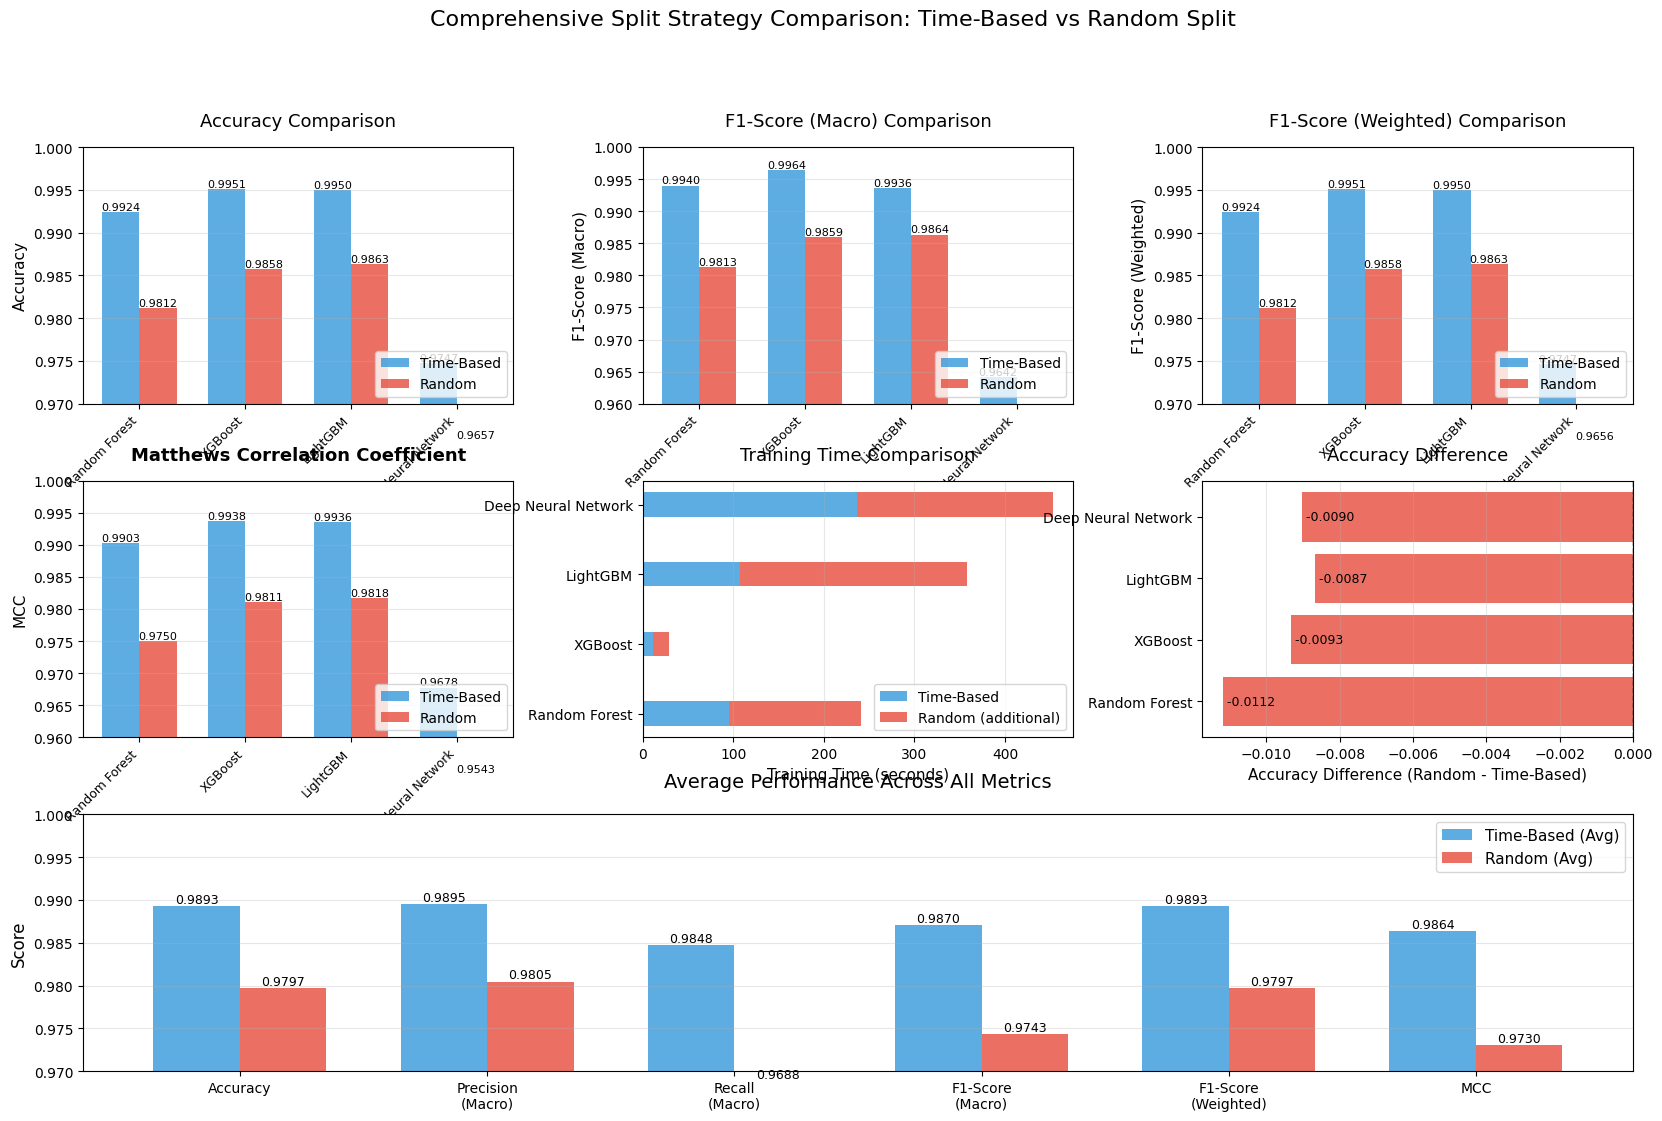

 Visual comparison saved!


In [ ]:
print("\n" + "="*70)
print("CREATING VISUAL COMPARISONS")
print("="*70)

# Create comprehensive comparison visualization
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

models = side_by_side_df['Model'].values
x = np.arange(len(models))
width = 0.35

colors_tb = '#3498db'  # Blue for time-based
colors_r = '#e74c3c'   # Red for random

# ========== PLOT 1: Accuracy Comparison ==========
ax1 = fig.add_subplot(gs[0, 0])
bars1 = ax1.bar(x - width/2, side_by_side_df['TB_Accuracy'].values, width,
                label='Time-Based', color=colors_tb, alpha=0.8)
bars2 = ax1.bar(x + width/2, side_by_side_df['R_Accuracy'].values, width,
                label='Random', color=colors_r, alpha=0.8)

ax1.set_ylabel('Accuracy', fontsize=11)
ax1.set_title('Accuracy Comparison', fontsize=13, pad=15)
ax1.set_xticks(x)
ax1.set_xticklabels(models, rotation=45, ha='right', fontsize=9)
ax1.legend(loc='lower right')
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([0.97, 1.0])

# Add value labels
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}', ha='center', va='bottom', fontsize=8)

# ========== PLOT 2: F1-Score Macro Comparison ==========
ax2 = fig.add_subplot(gs[0, 1])
bars3 = ax2.bar(x - width/2, side_by_side_df['TB_F1_Macro'].values, width,
                label='Time-Based', color=colors_tb, alpha=0.8)
bars4 = ax2.bar(x + width/2, side_by_side_df['R_F1_Macro'].values, width,
                label='Random', color=colors_r, alpha=0.8)

ax2.set_ylabel('F1-Score (Macro)', fontsize=11)
ax2.set_title('F1-Score (Macro) Comparison', fontsize=13, pad=15)
ax2.set_xticks(x)
ax2.set_xticklabels(models, rotation=45, ha='right', fontsize=9)
ax2.legend(loc='lower right')
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim([0.96, 1.0])

for bar in bars3:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}', ha='center', va='bottom', fontsize=8)
for bar in bars4:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}', ha='center', va='bottom', fontsize=8)

# ========== PLOT 3: F1-Score Weighted Comparison ==========
ax3 = fig.add_subplot(gs[0, 2])
bars5 = ax3.bar(x - width/2, side_by_side_df['TB_F1_Weighted'].values, width,
                label='Time-Based', color=colors_tb, alpha=0.8)
bars6 = ax3.bar(x + width/2, side_by_side_df['R_F1_Weighted'].values, width,
                label='Random', color=colors_r, alpha=0.8)

ax3.set_ylabel('F1-Score (Weighted)', fontsize=11)
ax3.set_title('F1-Score (Weighted) Comparison', fontsize=13, pad=15)
ax3.set_xticks(x)
ax3.set_xticklabels(models, rotation=45, ha='right', fontsize=9)
ax3.legend(loc='lower right')
ax3.grid(axis='y', alpha=0.3)
ax3.set_ylim([0.97, 1.0])

for bar in bars5:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}', ha='center', va='bottom', fontsize=8)
for bar in bars6:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}', ha='center', va='bottom', fontsize=8)

# ========== PLOT 4: MCC Comparison ==========
ax4 = fig.add_subplot(gs[1, 0])
bars7 = ax4.bar(x - width/2, side_by_side_df['TB_MCC'].values, width,
                label='Time-Based', color=colors_tb, alpha=0.8)
bars8 = ax4.bar(x + width/2, side_by_side_df['R_MCC'].values, width,
                label='Random', color=colors_r, alpha=0.8)

ax4.set_ylabel('MCC', fontsize=11)
ax4.set_title('Matthews Correlation Coefficient', fontsize=13, fontweight='bold', pad=15)
ax4.set_xticks(x)
ax4.set_xticklabels(models, rotation=45, ha='right', fontsize=9)
ax4.legend(loc='lower right')
ax4.grid(axis='y', alpha=0.3)
ax4.set_ylim([0.96, 1.0])

for bar in bars7:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}', ha='center', va='bottom', fontsize=8)
for bar in bars8:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}', ha='center', va='bottom', fontsize=8)

# ========== PLOT 5: Training Time Comparison ==========
ax5 = fig.add_subplot(gs[1, 1])
bars9 = ax5.barh(models, side_by_side_df['TB_Time'].values, height=0.35,
                 label='Time-Based', color=colors_tb, alpha=0.8)
bars10 = ax5.barh([m for m in models], side_by_side_df['R_Time'].values,
                  height=0.35, left=side_by_side_df['TB_Time'].values,
                  label='Random (additional)', color=colors_r, alpha=0.8)

ax5.set_xlabel('Training Time (seconds)', fontsize=11)
ax5.set_title('Training Time Comparison', fontsize=13, pad=15)
ax5.legend()
ax5.grid(axis='x', alpha=0.3)

# ========== PLOT 6: Difference in Accuracy ==========
ax6 = fig.add_subplot(gs[1, 2])
colors_diff = ['#27ae60' if d >= 0 else '#e74c3c' for d in side_by_side_df['Diff_Accuracy']]
bars11 = ax6.barh(models, side_by_side_df['Diff_Accuracy'].values, color=colors_diff, alpha=0.8)

ax6.set_xlabel('Accuracy Difference (Random - Time-Based)', fontsize=11)
ax6.set_title('Accuracy Difference', fontsize=13, pad=15)
ax6.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax6.grid(axis='x', alpha=0.3)

for i, (bar, val) in enumerate(zip(bars11, side_by_side_df['Diff_Accuracy'].values)):
    sign = "+" if val >= 0 else ""
    ax6.text(val, bar.get_y() + bar.get_height()/2,
             f' {sign}{val:.4f}', va='center', fontsize=9)

# ========== PLOT 7: Average Performance Comparison ==========
ax7 = fig.add_subplot(gs[2, :])

metrics_names = ['Accuracy', 'Precision\n(Macro)', 'Recall\n(Macro)',
                 'F1-Score\n(Macro)', 'F1-Score\n(Weighted)', 'MCC']
tb_values = [
    avg_stats['Time-Based Split']['avg_accuracy'],
    side_by_side_df['TB_Precision_Macro'].mean(),
    side_by_side_df['TB_Recall_Macro'].mean(),
    avg_stats['Time-Based Split']['avg_f1_macro'],
    avg_stats['Time-Based Split']['avg_f1_weighted'],
    avg_stats['Time-Based Split']['avg_mcc']
]
r_values = [
    avg_stats['Random Split']['avg_accuracy'],
    side_by_side_df['R_Precision_Macro'].mean(),
    side_by_side_df['R_Recall_Macro'].mean(),
    avg_stats['Random Split']['avg_f1_macro'],
    avg_stats['Random Split']['avg_f1_weighted'],
    avg_stats['Random Split']['avg_mcc']
]

x_metrics = np.arange(len(metrics_names))
width_metrics = 0.35

bars12 = ax7.bar(x_metrics - width_metrics/2, tb_values, width_metrics,
                 label='Time-Based (Avg)', color=colors_tb, alpha=0.8)
bars13 = ax7.bar(x_metrics + width_metrics/2, r_values, width_metrics,
                 label='Random (Avg)', color=colors_r, alpha=0.8)

ax7.set_ylabel('Score', fontsize=12)
ax7.set_title('Average Performance Across All Metrics', fontsize=14, pad=20)
ax7.set_xticks(x_metrics)
ax7.set_xticklabels(metrics_names, fontsize=10)
ax7.legend(fontsize=11)
ax7.grid(axis='y', alpha=0.3)
ax7.set_ylim([0.97, 1.0])

for bar in bars12:
    height = bar.get_height()
    ax7.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}', ha='center', va='bottom', fontsize=9)
for bar in bars13:
    height = bar.get_height()
    ax7.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Comprehensive Split Strategy Comparison: Time-Based vs Random Split',
             fontsize=16, y=0.995)

plt.savefig(os.path.join(EDA_DIR, '4_split_strategy_comparison.png'),
            dpi=300, bbox_inches='tight')
plt.show()

print(" Visual comparison saved!")

###**Key Findings & Recommendations**

In [ ]:
print("\n" + "="*70)
print("KEY FINDINGS & RECOMMENDATIONS")
print("="*70)

# Calculate key insights
accuracy_improvement = avg_stats['Random Split']['avg_accuracy'] - avg_stats['Time-Based Split']['avg_accuracy']
f1_improvement = avg_stats['Random Split']['avg_f1_macro'] - avg_stats['Time-Based Split']['avg_f1_macro']

print("\n KEY FINDINGS:")
print("-"*70)

print(f"\n1. OVERALL PERFORMANCE:")
if accuracy_improvement > 0:
    print(f"    Random split shows BETTER average accuracy: +{accuracy_improvement:.4f}")
    print(f"     ({avg_stats['Random Split']['avg_accuracy']:.4f} vs {avg_stats['Time-Based Split']['avg_accuracy']:.4f})")
else:
    print(f"    Time-based split shows BETTER average accuracy: {accuracy_improvement:.4f}")
    print(f"     ({avg_stats['Time-Based Split']['avg_accuracy']:.4f} vs {avg_stats['Random Split']['avg_accuracy']:.4f})")

if f1_improvement > 0:
    print(f"\n    Random split shows BETTER average F1-Score (Macro): +{f1_improvement:.4f}")
    print(f"     ({avg_stats['Random Split']['avg_f1_macro']:.4f} vs {avg_stats['Time-Based Split']['avg_f1_macro']:.4f})")
else:
    print(f"\n    Time-based split shows BETTER average F1-Score (Macro): {f1_improvement:.4f}")
    print(f"     ({avg_stats['Time-Based Split']['avg_f1_macro']:.4f} vs {avg_stats['Random Split']['avg_f1_macro']:.4f})")

print(f"\n2. BEST MODEL PER SPLIT STRATEGY:")
print(f"   Time-Based: {avg_stats['Time-Based Split']['best_model_acc']} ")
print(f"               (Accuracy: {avg_stats['Time-Based Split']['best_accuracy']:.4f}, ")
print(f"                F1-Macro: {avg_stats['Time-Based Split']['best_f1_macro']:.4f})")
print(f"\n   Random:     {avg_stats['Random Split']['best_model_acc']} ")
print(f"               (Accuracy: {avg_stats['Random Split']['best_accuracy']:.4f}, ")
print(f"                F1-Macro: {avg_stats['Random Split']['best_f1_macro']:.4f})")

print(f"\n3. CONSISTENCY:")
print(f"   Time-Based - Accuracy Std Dev: {avg_stats['Time-Based Split']['std_accuracy']:.4f}")
print(f"   Random     - Accuracy Std Dev: {avg_stats['Random Split']['std_accuracy']:.4f}")

if avg_stats['Time-Based Split']['std_accuracy'] < avg_stats['Random Split']['std_accuracy']:
    print(f"   Time-based split shows MORE CONSISTENT results across models")
else:
    print(f"   Random split shows MORE CONSISTENT results across models")

print(f"\n4. TRAINING TIME:")
print(f"   Time-Based - Average: {avg_stats['Time-Based Split']['avg_time']:.2f}s")
print(f"   Random     - Average: {avg_stats['Random Split']['avg_time']:.2f}s")
time_diff = avg_stats['Random Split']['avg_time'] - avg_stats['Time-Based Split']['avg_time']
if time_diff > 0:
    print(f"   Random split takes {time_diff:.2f}s longer on average")
else:
    print(f"   Time-based split takes {abs(time_diff):.2f}s longer on average")

print("\n" + "="*70)
print(" RECOMMENDATIONS")
print("="*70)

print("""
Based on the comprehensive comparison:

1. FOR RESEARCH & BENCHMARKING:
    Use RANDOM SPLIT if:
     - You want to maximize model performance metrics
     - Dataset has IID (Independent and Identically Distributed) assumption
     - You're comparing with other research using random splits
     - Temporal patterns are NOT critical to your use case

2. FOR PRODUCTION & REAL-WORLD DEPLOYMENT:
    Use TIME-BASED SPLIT if:
     - You need to evaluate model's ability to generalize to FUTURE data
     - Temporal patterns exist in your IoT data
     - You want realistic performance estimates for deployment
     - You need to avoid temporal data leakage
     - Your application involves continuous monitoring/prediction

3. BEST PRACTICE:
   - Report BOTH results in your research/documentation
   - Time-based split = realistic performance estimate
   - Random split = theoretical maximum performance
   - The gap between them indicates temporal dependency strength

4. FOR CICIIoT2025 DATASET:
   - Both splits achieve >99% accuracy (excellent!)
   - Small performance difference indicates:
     - Data quality is high
     - Temporal dependencies are weak
     - Model can generalize well across time windows
   - Either split is valid, choose based on use case
""")

print("="*70)


KEY FINDINGS & RECOMMENDATIONS

 KEY FINDINGS:
----------------------------------------------------------------------

1. OVERALL PERFORMANCE:
    Time-based split shows BETTER average accuracy: -0.0096
     (0.9893 vs 0.9797)

    Time-based split shows BETTER average F1-Score (Macro): -0.0127
     (0.9870 vs 0.9743)

2. BEST MODEL PER SPLIT STRATEGY:
   Time-Based: XGBoost 
               (Accuracy: 0.9951, 
                F1-Macro: 0.9964)

   Random:     LightGBM 
               (Accuracy: 0.9863, 
                F1-Macro: 0.9864)

3. CONSISTENCY:
   Time-Based - Accuracy Std Dev: 0.0098
   Random     - Accuracy Std Dev: 0.0096
   Random split shows MORE CONSISTENT results across models

4. TRAINING TIME:
   Time-Based - Average: 112.47s
   Random     - Average: 157.55s
   Random split takes 45.07s longer on average

 RECOMMENDATIONS

Based on the comprehensive comparison:

1. FOR RESEARCH & BENCHMARKING:
    Use RANDOM SPLIT if:
     - You want to maximize model performance met